# Comparative Analysis of Machine Learning and Deep Learning Models for Student Dropout Prediction

Student dropout is a major challenge for higher education institutions because it affects both students and universities. Early identification of at risk students can help institutions provide support before students leave their programmes.

This project uses the Predict Students' Dropout and Academic Success dataset from the UCI Machine Learning Repository. The objective is to compare traditional machine learning models with deep learning models and evaluate which approach generalises best on structured educational data.

## Dataset Overview

The dataset contains demographic, academic, and financial information collected from a Portuguese higher education institution. The target variable contains three classes: Graduate, Enrolled, and Dropout.

Although the dataset contains no missing values, class imbalance is present because the Enrolled class has fewer observations. This makes the prediction task more challenging and motivates the use of weighted evaluation metrics.


## 1.  Importing libraries



In [1]:
# !pip install numpy pandas matplotlib seaborn scikit-learn tensorflow

import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score,
    precision_recall_curve, average_precision_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')

print(f"NumPy {np.__version__} | Pandas {pd.__version__} | TF {tf.__version__}")


NumPy 2.0.2 | Pandas 2.2.2 | TF 2.20.0


## 2.  Loading Dataset


In [2]:
import os
_csv_name = 'student_dropout_data.csv'
_candidates = [_csv_name, f'../data/{_csv_name}', f'data/{_csv_name}', 'data.csv', f'../data/data.csv']
_path = next((p for p in _candidates if os.path.exists(p)), _csv_name)
df = pd.read_csv(_path, sep=';')
df.columns = df.columns.str.strip()

print("=" * 55)
print(f"  Shape : {df.shape[0]:,} rows x {df.shape[1]} columns")
print("=" * 55)
print()
df.head()

  Shape : 4,424 rows x 37 columns



,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
print("Descriptive Statistics:")
df.describe()

Descriptive Statistics:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [4]:
missing = df.isnull().sum()
print("Missing values:", "None" if missing.sum() == 0 else missing[missing > 0])
print(f"Duplicate rows: {df.duplicated().sum()}")
print()
print("Target Class Distribution:")
counts = df['Target'].value_counts()
for label, count in counts.items():
    print(f"  {label:<12}: {count:,}  ({count/len(df)*100:.1f}%)")

Missing values: None
Duplicate rows: 0

Target Class Distribution:
  Graduate    : 2,209  (49.9%)
  Dropout     : 1,421  (32.1%)
  Enrolled    : 794  (17.9%)


**Key observations:**
- No missing values, no duplicates the dataset is clean.
- Three target classes: **Graduate** (49.9%), **Dropout** (32.1%), **Enrolled** (17.9%).
- Moderate imbalance :Enrolled is underrepresented. We use `class_weight='balanced'` for all sklearn models and weighted F1/AUC for evaluation.
- All 36 features are already numerically encoded only standardisation is required.

## Exploratory Data Analysis

Exploratory analysis is performed to understand the distribution of the target classes and identify relationships between important variables. Correlation analysis and visualisations help reveal patterns that may influence student outcomes.

Understanding these relationships before modelling helps justify later preprocessing and feature engineering decisions.

### 3.1 Target Class Distribution

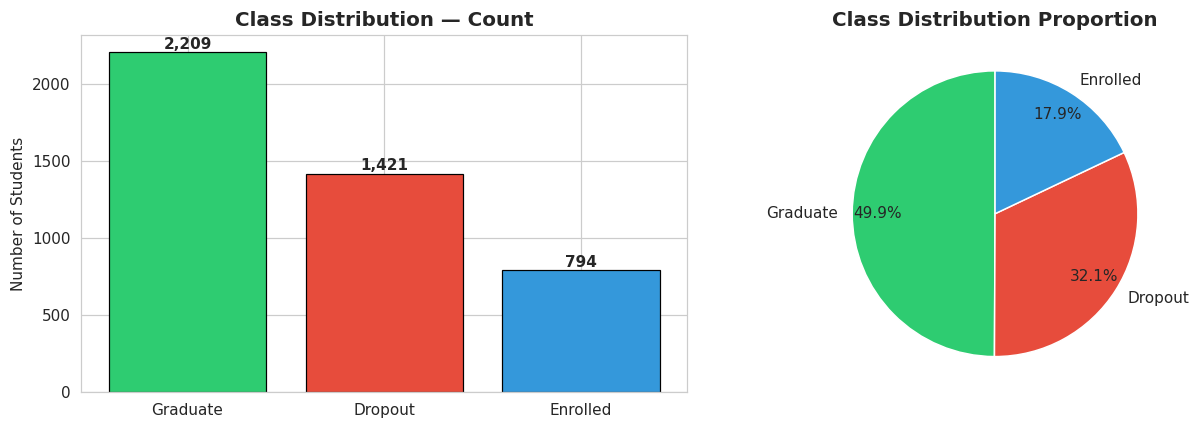

Figure 1: Moderately imbalanced  Enrolled is 18% of data.
Accuracy alone is misleading; weighted F1 and AUC are used throughout.


In [5]:
class_colors = {'Graduate': '#2ecc71', 'Dropout': '#e74c3c', 'Enrolled': '#3498db'}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts_s = df['Target'].value_counts()
bars = axes[0].bar(counts_s.index, counts_s.values,
                   color=[class_colors[k] for k in counts_s.index],
                   edgecolor='black', linewidth=0.8)
axes[0].set_title('Class Distribution — Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Students')
for bar, val in zip(bars, counts_s.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:,}', ha='center', fontweight='bold')

axes[1].pie(counts_s.values, labels=counts_s.index,
            colors=[class_colors[k] for k in counts_s.index],
            autopct='%1.1f%%', startangle=90, pctdistance=0.82)
axes[1].set_title('Class Distribution Proportion', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print("Figure 1: Moderately imbalanced  Enrolled is 18% of data.")
print("Accuracy alone is misleading; weighted F1 and AUC are used throughout.")

### 3.2 Feature Distributions by Class

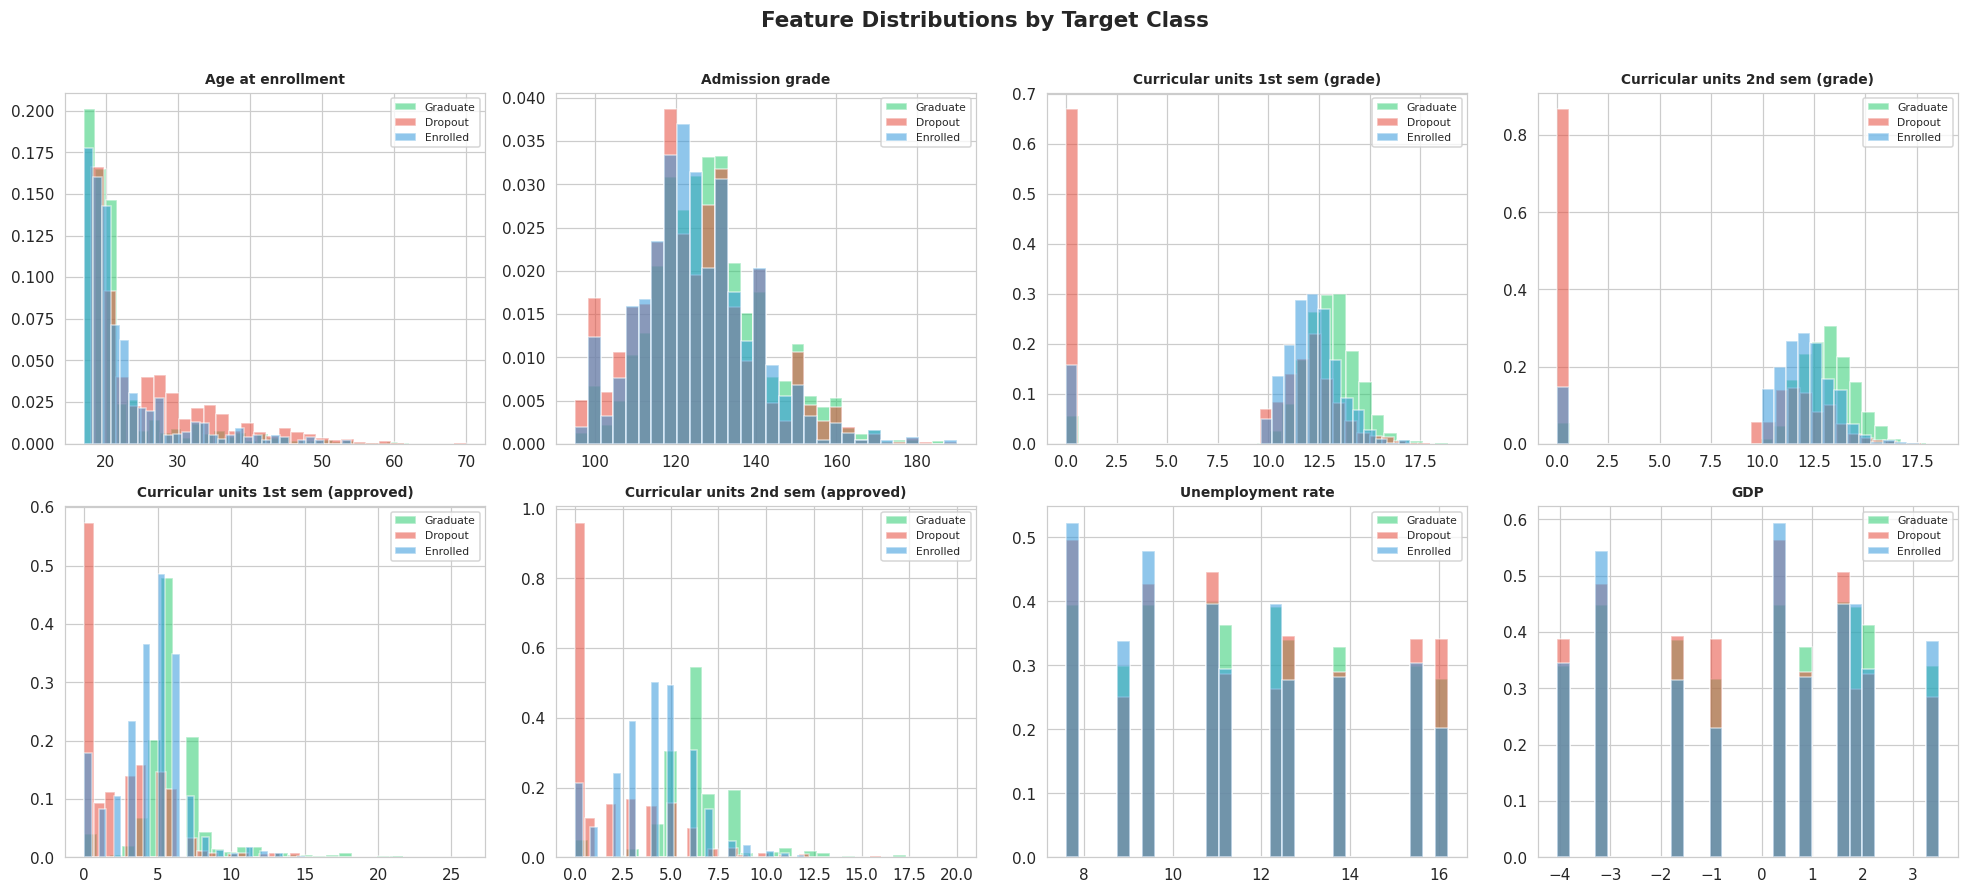

Figure 2: Semester grades and approved units show the clearest class separation.
Graduates cluster at high grades; Dropouts pile up near zero.
Economic features (Unemployment, GDP) show little class separation.


In [6]:
key_features = [
    'Age at enrollment', 'Admission grade',
    'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)',
    'Curricular units 1st sem (approved)', 'Curricular units 2nd sem (approved)',
    'Unemployment rate', 'GDP'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, feat in enumerate(key_features):
    for label, color in class_colors.items():
        axes[i].hist(df[df['Target'] == label][feat].dropna(),
                     bins=30, alpha=0.55, color=color, label=label,
                     density=True, edgecolor='white')
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].legend(fontsize=7)

plt.suptitle('Feature Distributions by Target Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

print("Figure 2: Semester grades and approved units show the clearest class separation.")
print("Graduates cluster at high grades; Dropouts pile up near zero.")
print("Economic features (Unemployment, GDP) show little class separation.")

### 3.3 Correlation Heatmap

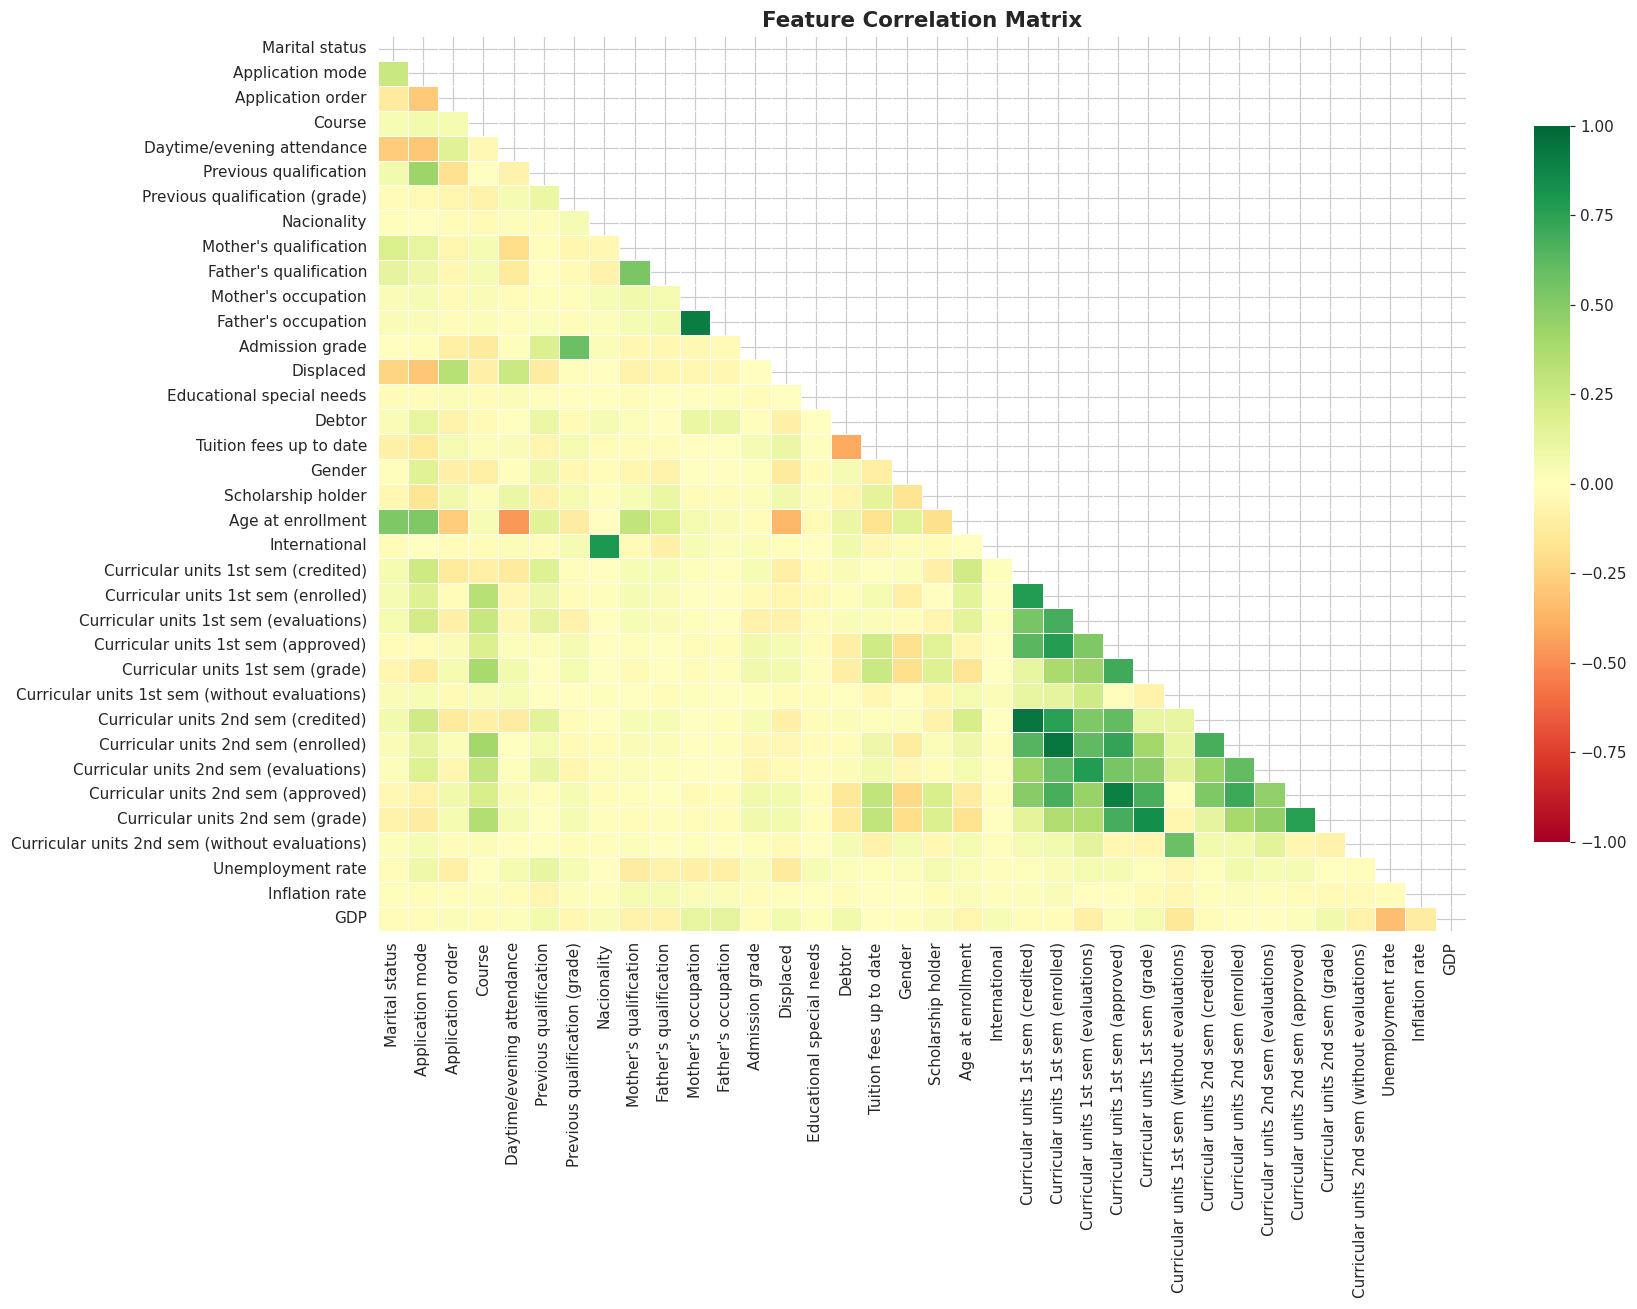

Figure 3: Strong positive correlations between 1st and 2nd semester performance features.
Parent education and occupation features are also intercorrelated.
All features retained  tree based models handle correlation naturally.


In [7]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdYlGn', center=0,
            annot=False, linewidths=0.4, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print("Figure 3: Strong positive correlations between 1st and 2nd semester performance features.")
print("Parent education and occupation features are also intercorrelated.")
print("All features retained  tree based models handle correlation naturally.")

### 3.4 Preliminary Feature Importance

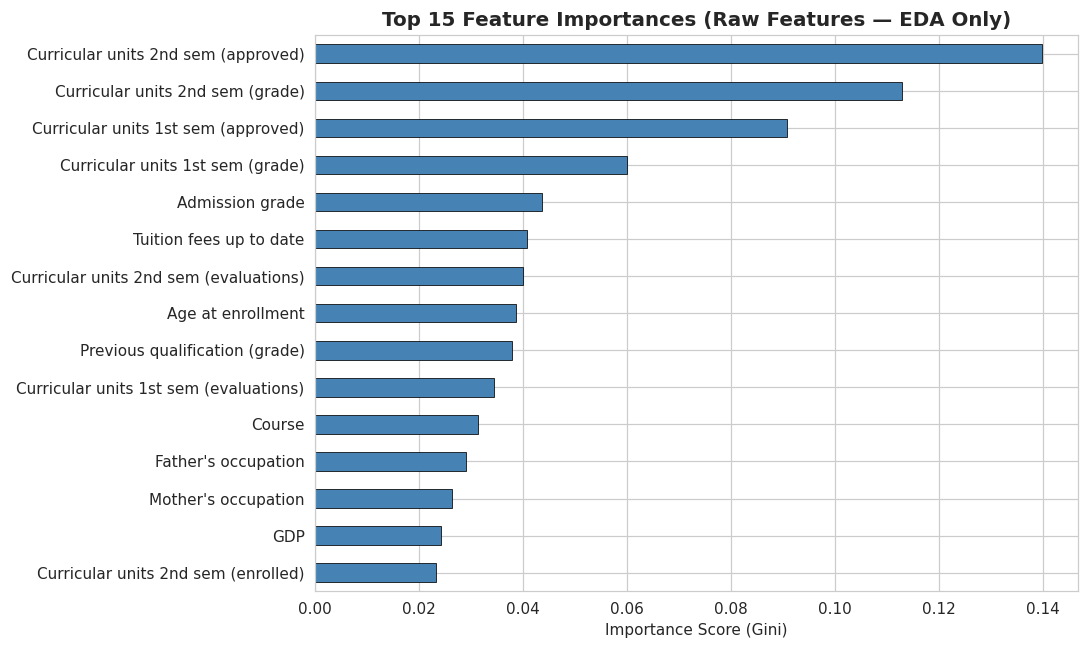

Figure 4: 2nd semester performance and tuition status dominate raw importance.
Engineered features (Section 4) will supplement these in all final models.


In [8]:
le_tmp = LabelEncoder()
y_tmp = le_tmp.fit_transform(df['Target'])
X_tmp = df.drop(columns=['Target'])

rf_tmp = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_tmp.fit(X_tmp, y_tmp)

imp_s = pd.Series(rf_tmp.feature_importances_, index=X_tmp.columns)
top15 = imp_s.nlargest(15).sort_values()

plt.figure(figsize=(10, 6))
top15.plot(kind='barh', color='steelblue', edgecolor='black', linewidth=0.5)
plt.title('Top 15 Feature Importances (Raw Features — EDA Only)', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score (Gini)')
plt.tight_layout(); plt.show()

print("Figure 4: 2nd semester performance and tuition status dominate raw importance.")
print("Engineered features (Section 4) will supplement these in all final models.")

## 4. Data Preprocessing & Feature Engineering

### Approach
1. **Engineer four composite features** that capture academic engagement, trajectory, and financial risk.
2. **Standardise** all features with `StandardScaler` fitted on training data only.
3. **Split** 70% train / 15% validation / 15% test (stratified).

### Engineered Features

Four additional features were created to capture relationships that are not explicitly represented in the original dataset. These include engagement_ratio, academic_progress, total_approved_units, and financial_risk.

These engineered features provide more meaningful information to the models and improve interpretability. They also help represent behavioural and financial factors that may contribute to dropout risk.

In [9]:
def engineer_features(df_input):
    df_fe = df_input.copy()
    enrolled_total = (df_fe['Curricular units 1st sem (enrolled)'] +
                      df_fe['Curricular units 2nd sem (enrolled)'])
    approved_total = (df_fe['Curricular units 1st sem (approved)'] +
                      df_fe['Curricular units 2nd sem (approved)'])

    df_fe['engagement_ratio'] = approved_total / (enrolled_total + 1)

    df_fe['academic_progress'] = (df_fe['Curricular units 2nd sem (grade)'] -
                                  df_fe['Curricular units 1st sem (grade)'])

    df_fe['total_approved'] = approved_total

    df_fe['financial_risk'] = (
        (df_fe['Debtor'] == 1) & (df_fe['Tuition fees up to date'] == 0)
    ).astype(int)

    return df_fe

df_engineered = engineer_features(df)
new_features = ['engagement_ratio', 'academic_progress', 'total_approved', 'financial_risk']

print(f"Original features : {df.shape[1] - 1}")
print(f"After engineering : {df_engineered.shape[1] - 1}")
print()
print("Engineered Feature Statistics:")
print(df_engineered[new_features].describe().round(3))

Original features : 36
After engineering : 40

Engineered Feature Statistics:
       engagement_ratio  academic_progress  total_approved  financial_risk
count          4424.000           4424.000        4424.000        4424.000
mean              0.630             -0.411           9.142           0.056
std               0.336              2.890           5.961           0.229
min               0.000            -16.143           0.000           0.000
25%               0.455             -0.600           5.000           0.000
50%               0.769              0.000          10.000           0.000
75%               0.909              0.452          12.000           0.000
max               0.977             16.000          43.000           1.000


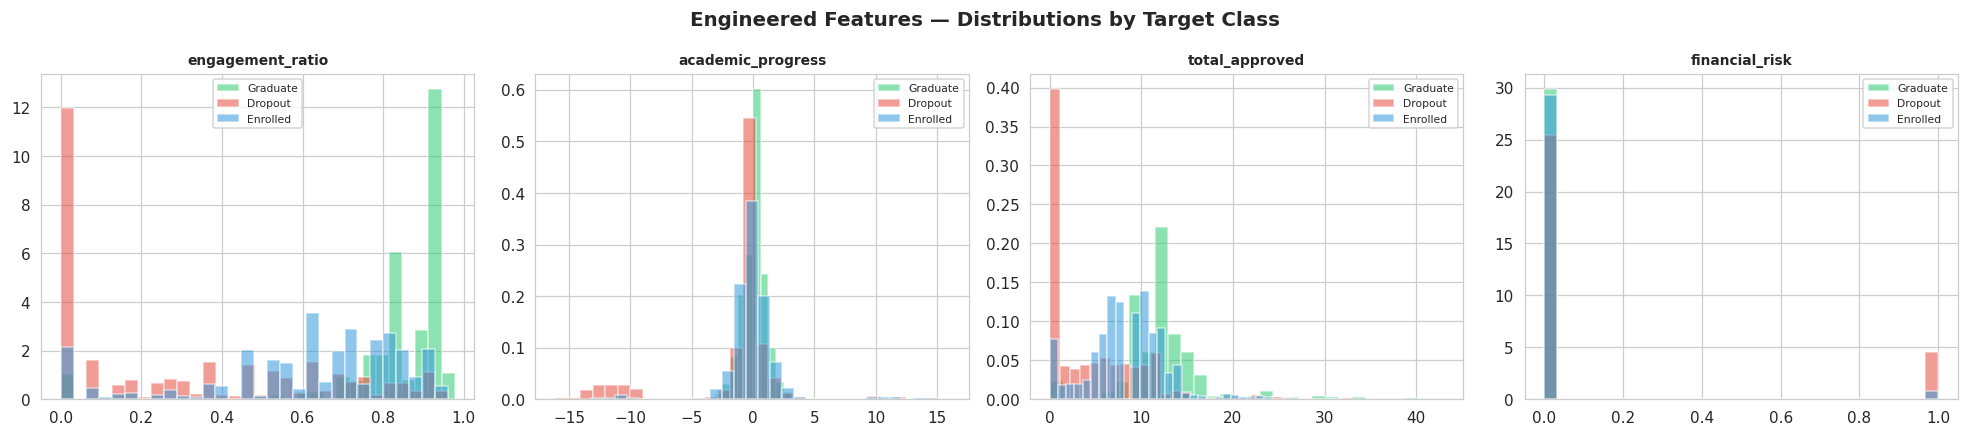

Figure 5: engagement_ratio shows the strongest class separation of all engineered features.
financial_risk is binary: Dropouts are overrepresented in the risk=1 bin.


In [10]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, feat in zip(axes, new_features):
    for label, color in class_colors.items():
        ax.hist(df_engineered[df_engineered['Target'] == label][feat],
                bins=30, alpha=0.55, color=color, label=label,
                density=True, edgecolor='white')
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.legend(fontsize=7)

plt.suptitle('Engineered Features — Distributions by Target Class', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print("Figure 5: engagement_ratio shows the strongest class separation of all engineered features.")
print("financial_risk is binary: Dropouts are overrepresented in the risk=1 bin.")

In [11]:

X = df_engineered.drop(columns=['Target'])
y_raw = df_engineered['Target']

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)   # Dropout=0, Enrolled=1, Graduate=2
CLASS_NAMES = label_encoder.classes_

print("Label encoding:")
for cls, enc in zip(CLASS_NAMES, label_encoder.transform(CLASS_NAMES)):
    print(f"  {cls} -> {enc}")
print()

X_train_raw, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp
)

print(f"Train : {X_train_raw.shape[0]:,}  ({X_train_raw.shape[0]/len(X)*100:.0f}%)")
print(f"Val   : {X_val_raw.shape[0]:,}   ({X_val_raw.shape[0]/len(X)*100:.0f}%)")
print(f"Test  : {X_test_raw.shape[0]:,}   ({X_test_raw.shape[0]/len(X)*100:.0f}%)")

Label encoding:
  Dropout -> 0
  Enrolled -> 1
  Graduate -> 2

Train : 3,096  (70%)
Val   : 664   (15%)
Test  : 664   (15%)


In [12]:
# StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val   = scaler.transform(X_val_raw)
X_test  = scaler.transform(X_test_raw)

X_train_f32 = X_train.astype(np.float32)
X_val_f32   = X_val.astype(np.float32)
X_test_f32  = X_test.astype(np.float32)
y_train_i32 = y_train.astype(np.int32)
y_val_i32   = y_val.astype(np.int32)
y_test_i32  = y_test.astype(np.int32)

N_FEATURES = X_train.shape[1]
N_CLASSES  = len(CLASS_NAMES)

print(f"Scaling complete. Fitted on training data only OK")
print(f"Feature matrix : {X_train.shape}  |  Classes : {N_CLASSES}")

Scaling complete. Fitted on training data only OK
Feature matrix : (3096, 40)  |  Classes : 3


**Preprocessing decisions:**
- All 40 features (36 original + 4 engineered) are numerical `StandardScaler` applied uniformly.
- Scaler **fitted on training data only**  prevents information leakage to val/test sets.
- Stratified split ensures each class is proportionally represented in all three partitions.
- `class_weight='balanced'` used in all sklearn models to handle the 18% Enrolled minority.

## 5. Traditional Machine Learning (Scikit-learn)

Four experiments in increasing model complexity:
- **Exp 1** — Logistic Regression (linear baseline)
- **Exp 2** — Decision Tree (interpretable, non-linear)
- **Exp 3** — Random Forest (default settings ensemble baseline)
- **Exp 4** — Random Forest (tuned hyperparameters)

In [13]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name):
    """Train an sklearn model and return a full metrics dictionary."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te).astype(np.int64)
    y_te   = np.array(y_te, dtype=np.int64)
    y_tr   = np.array(y_tr, dtype=np.int64)

    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred, average='weighted')
    prec = precision_score(y_te, y_pred, average='weighted')
    rec  = recall_score(y_te, y_pred, average='weighted')

    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_te)
    else:
        s = model.decision_function(X_te)
        e = np.exp(s - s.max(axis=1, keepdims=True))
        y_proba = e / e.sum(axis=1, keepdims=True)

    y_te_bin = label_binarize(y_te, classes=[0, 1, 2])
    auc = roc_auc_score(y_te_bin, y_proba, average='macro', multi_class='ovr')

    # Train F1 — predict on training data
    train_pred = model.predict(X_tr).astype(np.int64)
    train_f1   = f1_score(y_tr, train_pred, average='weighted')

    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"  Accuracy (test)  : {acc:.4f}")
    print(f"  F1       (test)  : {f1:.4f}  |  Train F1: {train_f1:.4f}  |  Gap: {train_f1-f1:.4f}")
    print(f"  Precision(test)  : {prec:.4f}")
    print(f"  Recall   (test)  : {rec:.4f}")
    print(f"  ROC-AUC  (test)  : {auc:.4f}")
    print()
    print(classification_report(y_te, y_pred, target_names=CLASS_NAMES))

    return {'model_name': model_name, 'model_obj': model,
            'accuracy': acc, 'f1': f1, 'train_f1': train_f1,
            'precision': prec, 'recall': rec, 'auc': auc,
            'y_pred': y_pred, 'y_proba': y_proba}

results = []
print("Evaluation helper defined OK")

Evaluation helper defined OK


### Experiment 1_Logistic Regression (Linear Baseline)

In [14]:
print("EXPERIMENT 1 — Logistic Regression")
print("Rationale: Assumes a linear decision boundary. Sets a lower-bound benchmark.")
print("           Any non-linear model that cannot beat this offers no benefit from")
print("           added complexity. class_weight='balanced' corrects for 18% Enrolled minority.\n")

lr = LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced')
res1 = evaluate_model(lr, X_train, y_train, X_test, y_test, "Exp 1 — Logistic Regression")
results.append(res1)

EXPERIMENT 1 — Logistic Regression
Rationale: Assumes a linear decision boundary. Sets a lower-bound benchmark.
           Any non-linear model that cannot beat this offers no benefit from
           added complexity. class_weight='balanced' corrects for 18% Enrolled minority.


  Exp 1 — Logistic Regression
  Accuracy (test)  : 0.7575
  F1       (test)  : 0.7704  |  Train F1: 0.7680  |  Gap: -0.0024
  Precision(test)  : 0.7976
  Recall   (test)  : 0.7575
  ROC-AUC  (test)  : 0.8990

              precision    recall  f1-score   support

     Dropout       0.87      0.71      0.79       214
    Enrolled       0.44      0.66      0.53       119
    Graduate       0.88      0.82      0.85       331

    accuracy                           0.76       664
   macro avg       0.73      0.73      0.72       664
weighted avg       0.80      0.76      0.77       664



### Experiment 2 — Decision Tree (Interpretable Non-Linear)

In [15]:
print("EXPERIMENT 2 — Decision Tree")
print("Rationale: Captures non-linear splits in the feature space. max_depth=8 prevents")
print("           full memorisation. Key advantage: rules can be exported and explained")
print("           to academic advisors without ML expertise.\n")

dt = DecisionTreeClassifier(max_depth=8, min_samples_split=20, min_samples_leaf=10,
                             random_state=SEED, class_weight='balanced')
res2 = evaluate_model(dt, X_train, y_train, X_test, y_test, "Exp 2 — Decision Tree")
results.append(res2)

EXPERIMENT 2 — Decision Tree
Rationale: Captures non-linear splits in the feature space. max_depth=8 prevents
           full memorisation. Key advantage: rules can be exported and explained
           to academic advisors without ML expertise.


  Exp 2 — Decision Tree
  Accuracy (test)  : 0.7319
  F1       (test)  : 0.7433  |  Train F1: 0.7978  |  Gap: 0.0545
  Precision(test)  : 0.7655
  Recall   (test)  : 0.7319
  ROC-AUC  (test)  : 0.8541

              precision    recall  f1-score   support

     Dropout       0.78      0.67      0.72       214
    Enrolled       0.43      0.63      0.51       119
    Graduate       0.88      0.81      0.84       331

    accuracy                           0.73       664
   macro avg       0.70      0.70      0.69       664
weighted avg       0.77      0.73      0.74       664



### Experiment 3 — Random Forest (Default Settings)

In [16]:
print("EXPERIMENT 3 — Random Forest (Default)")
print("Rationale: Averaging 100 randomised trees reduces variance vs a single tree.")
print("           Tests whether ensemble averaging alone — no tuning — beats the Decision Tree.\n")

rf_default = RandomForestClassifier(n_estimators=100, random_state=SEED,
                                     class_weight='balanced', n_jobs=-1)
res3 = evaluate_model(rf_default, X_train, y_train, X_test, y_test,
                      "Exp 3 — Random Forest (Default)")
results.append(res3)

EXPERIMENT 3 — Random Forest (Default)
Rationale: Averaging 100 randomised trees reduces variance vs a single tree.
           Tests whether ensemble averaging alone — no tuning — beats the Decision Tree.


  Exp 3 — Random Forest (Default)
  Accuracy (test)  : 0.8102
  F1       (test)  : 0.7988  |  Train F1: 1.0000  |  Gap: 0.2012
  Precision(test)  : 0.7982
  Recall   (test)  : 0.8102
  ROC-AUC  (test)  : 0.9113

              precision    recall  f1-score   support

     Dropout       0.84      0.82      0.83       214
    Enrolled       0.62      0.42      0.50       119
    Graduate       0.83      0.94      0.88       331

    accuracy                           0.81       664
   macro avg       0.77      0.73      0.74       664
weighted avg       0.80      0.81      0.80       664



### Experiment 4 _Random Forest (Tuned)

In [17]:
print("EXPERIMENT 4 — Random Forest (Tuned)")
print("Rationale: n_estimators=300 improves stability. Capping max_depth and raising")
print("           min_samples_split/leaf forces generalisation rather than memorisation.")
print("           max_features='sqrt' adds randomness, preventing dominant features")
print("           from overwhelming every tree split.\n")

rf_tuned = RandomForestClassifier(n_estimators=300, max_depth=12,
                                   min_samples_split=10, min_samples_leaf=4,
                                   max_features='sqrt', random_state=SEED,
                                   class_weight='balanced', n_jobs=-1)
res4 = evaluate_model(rf_tuned, X_train, y_train, X_test, y_test,
                      "Exp 4 — Random Forest (Tuned)")
results.append(res4)

EXPERIMENT 4 — Random Forest (Tuned)
Rationale: n_estimators=300 improves stability. Capping max_depth and raising
           min_samples_split/leaf forces generalisation rather than memorisation.
           max_features='sqrt' adds randomness, preventing dominant features
           from overwhelming every tree split.


  Exp 4 — Random Forest (Tuned)
  Accuracy (test)  : 0.7952
  F1       (test)  : 0.7994  |  Train F1: 0.8791  |  Gap: 0.0797
  Precision(test)  : 0.8080
  Recall   (test)  : 0.7952
  ROC-AUC  (test)  : 0.9122

              precision    recall  f1-score   support

     Dropout       0.88      0.76      0.82       214
    Enrolled       0.51      0.61      0.56       119
    Graduate       0.87      0.88      0.87       331

    accuracy                           0.80       664
   macro avg       0.75      0.75      0.75       664
weighted avg       0.81      0.80      0.80       664



## 6. Feature Importance Analysis

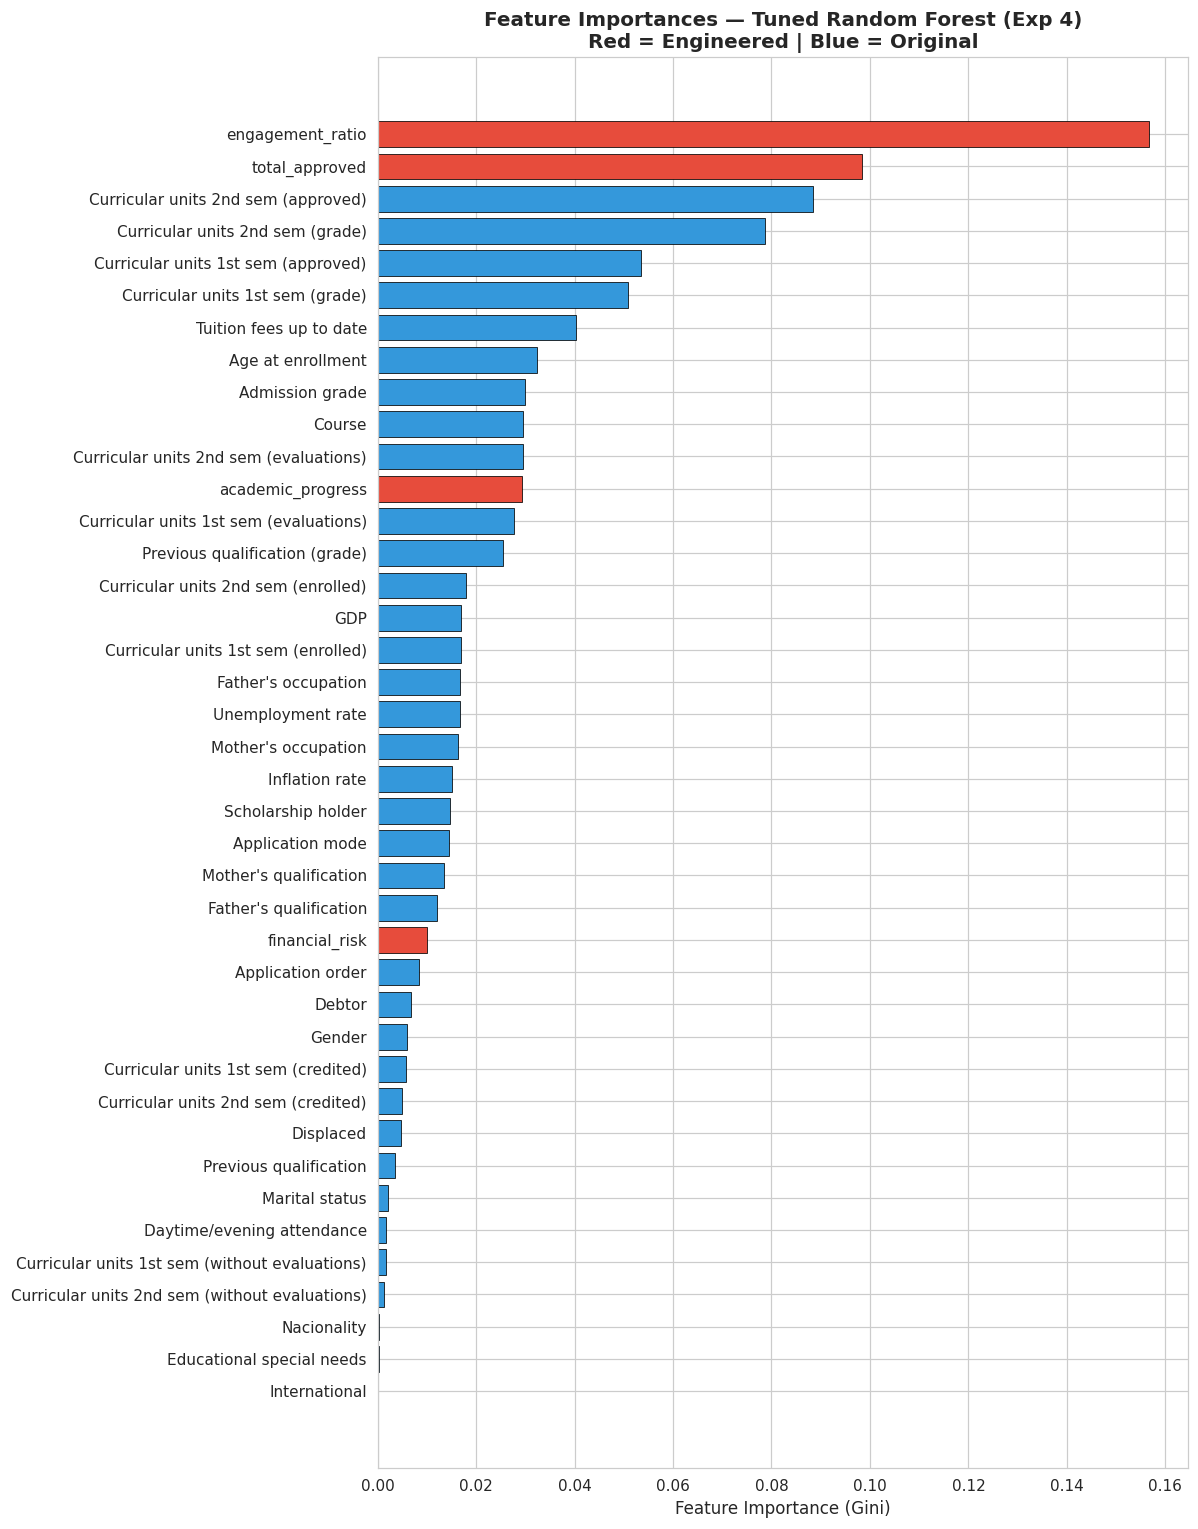

Top 5 features:
  Curricular units 1st sem (approved): 0.0535
  Curricular units 2nd sem (grade): 0.0788
  Curricular units 2nd sem (approved): 0.0885
  total_approved: 0.0984 [engineered]
  engagement_ratio: 0.1568 [engineered]

Figure 6: All 4 engineered features rank in the top half — engineering added signal.


In [18]:
importances = res4['model_obj'].feature_importances_
imp_df = pd.DataFrame({'Feature': X.columns.tolist(), 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=True)

eng_feats = ['engagement_ratio', 'academic_progress', 'total_approved', 'financial_risk']
colors_imp = ['#e74c3c' if f in eng_feats else '#3498db' for f in imp_df['Feature']]

plt.figure(figsize=(11, 14))
plt.barh(imp_df['Feature'], imp_df['Importance'],
         color=colors_imp, edgecolor='black', linewidth=0.5)
plt.xlabel('Feature Importance (Gini)', fontsize=11)
plt.title('Feature Importances — Tuned Random Forest (Exp 4)\n'
          'Red = Engineered | Blue = Original', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print("Top 5 features:")
for _, row in imp_df.tail(5).iterrows():
    tag = " [engineered]" if row['Feature'] in eng_feats else ""
    print(f"  {row['Feature']}: {row['Importance']:.4f}{tag}")
print()
print("Figure 6: All 4 engineered features rank in the top half — engineering added signal.")

## 7. Confusion Matrices FOR Traditional ML

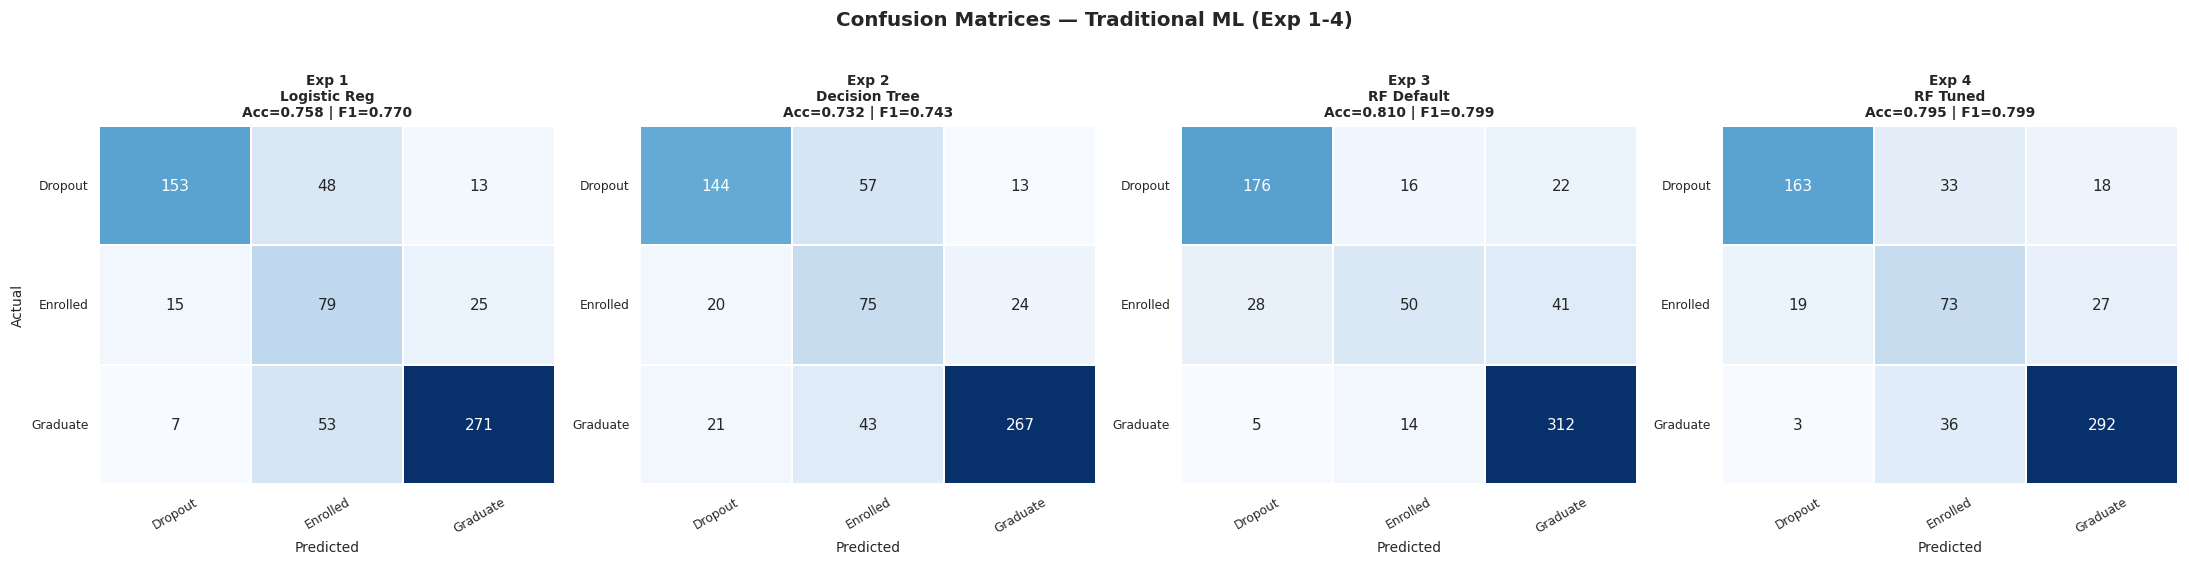

Figure 7: Enrolled class is consistently confused with Graduate and Dropout.
Tuned RF (Exp 4) shows the most balanced error distribution among traditional models.


In [19]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
labels_ml = ['Exp 1\nLogistic Reg', 'Exp 2\nDecision Tree',
              'Exp 3\nRF Default', 'Exp 4\nRF Tuned']

for ax, res, label in zip(axes, results[:4], labels_ml):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=1, cbar=False)
    ax.set_title(f'{label}\nAcc={res["accuracy"]:.3f} | F1={res["f1"]:.3f}',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Actual' if ax is axes[0] else '', fontsize=9)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)

plt.suptitle('Confusion Matrices — Traditional ML (Exp 1-4)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print("Figure 7: Enrolled class is consistently confused with Graduate and Dropout.")
print("Tuned RF (Exp 4) shows the most balanced error distribution among traditional models.")

## 8. Deep Learning with TensorFlow / Keras

### Pipeline Architecture
All DL models use the same `tf.data` input pipeline. Sequential API (Exp 5-6) and Functional API (Exp 7-8) are both demonstrated.


In [20]:
BATCH_SIZE = 64

def make_dataset(X_arr, y_arr, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X_arr, y_arr))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X_arr), seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(X_train_f32, y_train_i32, shuffle=True)
val_ds   = make_dataset(X_val_f32,   y_val_i32)
test_ds  = make_dataset(X_test_f32,  y_test_i32)

print(f"tf.data pipeline built OK")
print(f"  Input dim  : {N_FEATURES} | Batch: {BATCH_SIZE} | Train batches: {len(list(train_ds))}")

tf.data pipeline built OK
  Input dim  : 40 | Batch: 64 | Train batches: 49


In [21]:
def get_callbacks(save_path, patience_es=8, patience_lr=4):
    return [
        EarlyStopping(monitor='val_loss', patience=patience_es,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=patience_lr, min_lr=1e-6, verbose=0),
        ModelCheckpoint(filepath=save_path, save_best_only=True,
                        monitor='val_loss', verbose=0)
    ]

def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    ax1.plot(history.history['accuracy'],     label='Train', linewidth=2, color='steelblue')
    ax1.plot(history.history['val_accuracy'], label='Val',   linewidth=2,
             linestyle='--', color='tomato')
    ax1.set_title(f'{title} - Accuracy', fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(history.history['loss'],     label='Train', linewidth=2, color='steelblue')
    ax2.plot(history.history['val_loss'], label='Val',   linewidth=2,
             linestyle='--', color='tomato')
    ax2.set_title(f'{title} - Loss', fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

def eval_dl(model, X_te, y_te, name,
            X_tr=None, y_tr=None):
    """
    Evaluate a trained Keras model.
    X_tr / y_tr are passed explicitly to compute Train F1 —
    avoids any dependency on global variable state.
    """

    if X_tr is None:
        X_tr = X_train_f32
    if y_tr is None:
        y_tr = y_train

    y_proba = model.predict(X_te, verbose=0)
    y_pred  = np.argmax(y_proba, axis=1).astype(np.int64)

    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred, average='weighted')
    prec = precision_score(y_te, y_pred, average='weighted')
    rec  = recall_score(y_te, y_pred, average='weighted')

    y_te_bin = label_binarize(y_te, classes=[0, 1, 2])
    auc = roc_auc_score(y_te_bin, y_proba, average='macro', multi_class='ovr')

    tr_proba = model.predict(X_tr, verbose=0)
    tr_pred  = np.argmax(tr_proba, axis=1).astype(np.int64)
    train_f1 = f1_score(y_tr.astype(np.int64), tr_pred, average='weighted')

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  F1 (test) : {f1:.4f}  | Train F1: {train_f1:.4f}  | Gap: {train_f1-f1:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  ROC-AUC   : {auc:.4f}")
    print()
    print(classification_report(y_te, y_pred, target_names=CLASS_NAMES))

    return {'model_name': name, 'model_obj': model,
            'accuracy': acc, 'f1': f1, 'train_f1': train_f1,
            'precision': prec, 'recall': rec, 'auc': auc,
            'y_pred': y_pred, 'y_proba': y_proba}

print("DL utilities defined OK")

DL utilities defined OK


### Experiment 5 _Sequential API: Baseline Neural Network

EXPERIMENT 5 — Baseline NN (Sequential API)
Rationale: Three dense layers with ReLU capture non-linear interactions that
           Logistic Regression misses. No regularisation applied — minimal
           viable DL starting point. Expect mild overfitting.



Model: "Exp5_Baseline_NN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,683 (61.26 KB)

 Trainable params: 15,683 (61.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6744 - loss: 0.7949 - val_accuracy: 0.7289 - val_loss: 0.6822 - learning_rate: 0.0010
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7552 - loss: 0.5953 - val_accuracy: 0.7470 - val_loss: 0.6512 - learning_rate: 0.0010
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7778 - loss: 0.5464 - val_accuracy: 0.7425 - val_loss: 0.6540 - learning_rate: 0.0010
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7939 - loss: 0.5178 - val_accuracy: 0.7515 - val_loss: 0.6425 - learning_rate: 0.0010
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8010 - loss: 0.5003 - val_accuracy: 0.7530 - val_loss: 0.6374 - learning_rate: 0.0010
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8098 - loss: 0.4768 - val_accuracy: 0.7395 - val_loss: 0.6377 - learning_rate: 0.0010
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8159 - loss: 0.4607 - val_accuracy: 

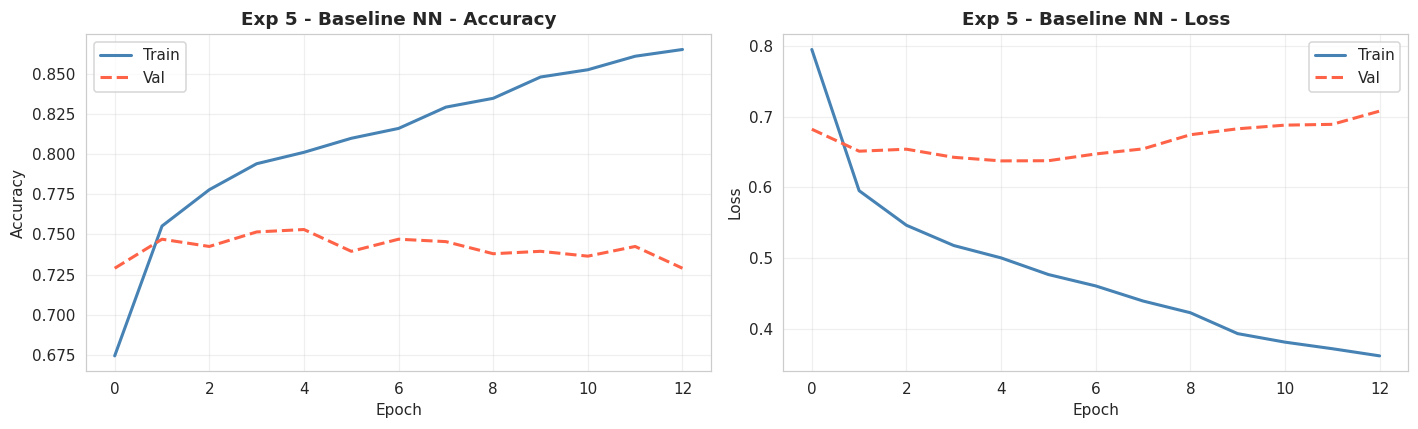

In [22]:
print("EXPERIMENT 5 — Baseline NN (Sequential API)")
print("Rationale: Three dense layers with ReLU capture non-linear interactions that")
print("           Logistic Regression misses. No regularisation applied — minimal")
print("           viable DL starting point. Expect mild overfitting.\n")

model5 = keras.Sequential([
    layers.Input(shape=(N_FEATURES,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64,  activation='relu'),
    layers.Dense(32,  activation='relu'),
    layers.Dense(N_CLASSES, activation='softmax')
], name="Exp5_Baseline_NN")

model5.compile(optimizer=keras.optimizers.Adam(1e-3),
               loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model5.summary()

hist5 = model5.fit(train_ds, validation_data=val_ds, epochs=50,
                   callbacks=get_callbacks('best_model5.keras'), verbose=1)
res5 = eval_dl(model5, X_test_f32, y_test, "Exp 5 - Baseline NN")
results.append(res5)
print(f"Stopped at epoch: {len(hist5.history['loss'])}")
plot_history(hist5, "Exp 5 - Baseline NN")

**Exp 5:**
Watch for a widening gap between training and validation loss. If val_loss plateaus or rises while train_loss keeps falling, the network is overfitting memorising training noise. EarlyStopping limits damage, but without regularisation, a clear train-val divergence is expected.

### Experiment 6 _Sequential API: NN + Dropout

EXPERIMENT 6 — NN + Dropout (Sequential API)
Rationale: Dropout randomly deactivates neurons during training, preventing
           co-adaptation. Forces the network to learn redundant representations.
           Decreasing rates (0.4->0.3->0.2) with depth is a common heuristic:
           early layers need stronger regularisation than specialised later ones.



Model: "Exp6_Dropout_NN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,683 (61.26 KB)

 Trainable params: 15,683 (61.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5992 - loss: 0.9362 - val_accuracy: 0.7018 - val_loss: 0.7445 - learning_rate: 0.0010
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7080 - loss: 0.7437 - val_accuracy: 0.7259 - val_loss: 0.6905 - learning_rate: 0.0010
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7345 - loss: 0.6802 - val_accuracy: 0.7470 - val_loss: 0.6664 - learning_rate: 0.0010
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7364 - loss: 0.6611 - val_accuracy: 0.7530 - val_loss: 0.6581 - learning_rate: 0.0010
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7542 - loss: 0.6419 - val_accuracy: 0.7575 - val_loss: 0.6499 - learning_rate: 0.0010
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7536 - loss: 0.6236 - val_accuracy: 0.7620 - val_loss: 0.6489 - learning_rate: 0.0010
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7477 - loss: 0.6131 - val_accuracy: 

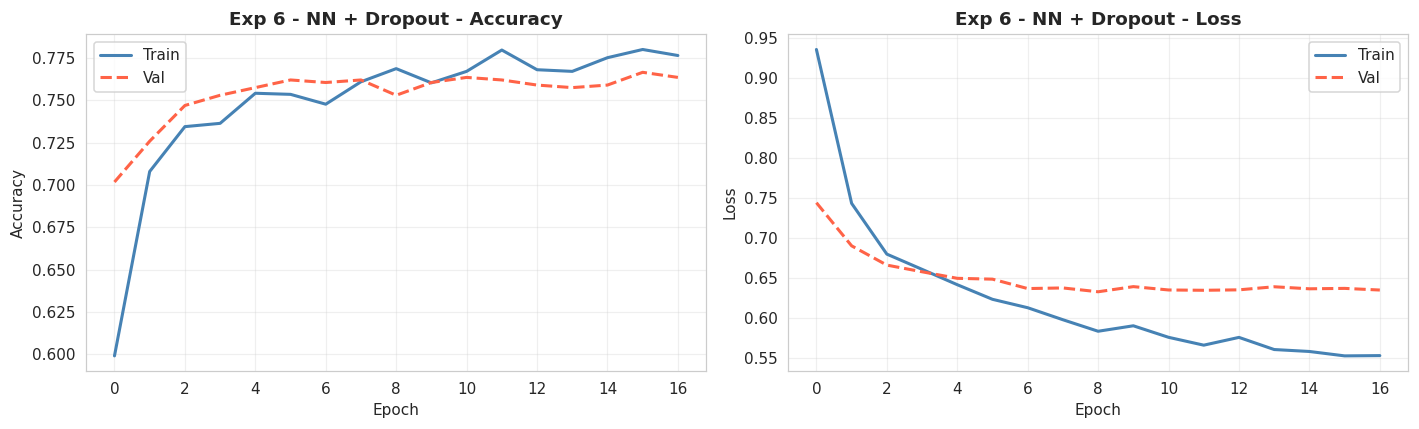

In [23]:
print("EXPERIMENT 6 — NN + Dropout (Sequential API)")
print("Rationale: Dropout randomly deactivates neurons during training, preventing")
print("           co-adaptation. Forces the network to learn redundant representations.")
print("           Decreasing rates (0.4->0.3->0.2) with depth is a common heuristic:")
print("           early layers need stronger regularisation than specialised later ones.\n")

model6 = keras.Sequential([
    layers.Input(shape=(N_FEATURES,)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(64,  activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32,  activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(N_CLASSES, activation='softmax')
], name="Exp6_Dropout_NN")

model6.compile(optimizer=keras.optimizers.Adam(1e-3),
               loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model6.summary()

hist6 = model6.fit(train_ds, validation_data=val_ds, epochs=50,
                   callbacks=get_callbacks('best_model6.keras'), verbose=1)
res6 = eval_dl(model6, X_test_f32, y_test, "Exp 6 - NN + Dropout")
results.append(res6)
print(f"Stopped at epoch: {len(hist6.history['loss'])}")
plot_history(hist6, "Exp 6 - NN + Dropout")



**Exp 6:**
Training accuracy will appear *lower* than Exp 5 during training. this is expected. Dropout reduces effective network capacity at each step. The key diagnostic: if the val curve now tracks the training curve more closely than in Exp 5, Dropout is successfully reducing variance.

### Experiment 7 _Functional API: NN + Batch Normalisation

EXPERIMENT 7 — NN + Batch Normalisation (Functional API)
Rationale: BatchNorm normalises activations per mini-batch, reducing internal
           covariate shift and stabilising gradient flow. Enables faster
           convergence and smoother loss curves. Functional API is used to
           demonstrate graph-style construction.



Model: "Exp7_BatchNorm_NN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ student_features (InputLayer)   │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probs (Dense)             │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,579 (64.76 KB)

 Trainable params: 16,131 (63.01 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6095 - loss: 0.8739 - val_accuracy: 0.7048 - val_loss: 0.8070 - learning_rate: 0.0010
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7532 - loss: 0.6143 - val_accuracy: 0.7244 - val_loss: 0.7074 - learning_rate: 0.0010
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7804 - loss: 0.5564 - val_accuracy: 0.7380 - val_loss: 0.6686 - learning_rate: 0.0010
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8001 - loss: 0.5117 - val_accuracy: 0.7364 - val_loss: 0.6618 - learning_rate: 0.0010
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8065 - loss: 0.4866 - val_accuracy: 0.7304 - val_loss: 0.6625 - learning_rate: 0.0010
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8194 - loss: 0.4628 - val_accuracy: 0.7289 - val_loss: 0.6906 - learning_rate: 0.0010
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8178 - loss: 0.4466 - val_accuracy: 

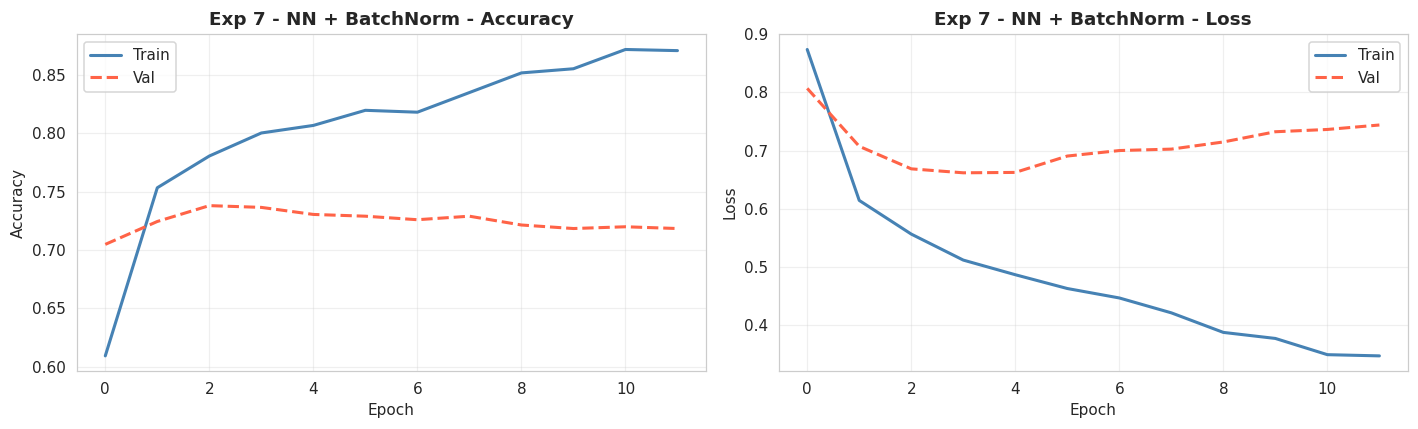

In [24]:
print("EXPERIMENT 7 — NN + Batch Normalisation (Functional API)")
print("Rationale: BatchNorm normalises activations per mini-batch, reducing internal")
print("           covariate shift and stabilising gradient flow. Enables faster")
print("           convergence and smoother loss curves. Functional API is used to")
print("           demonstrate graph-style construction.\n")

inputs = layers.Input(shape=(N_FEATURES,), name='student_features')
x = layers.Dense(128, activation='relu', name='dense_1')(inputs)
x = layers.BatchNormalization(name='bn_1')(x)
x = layers.Dense(64,  activation='relu', name='dense_2')(x)
x = layers.BatchNormalization(name='bn_2')(x)
x = layers.Dense(32,  activation='relu', name='dense_3')(x)
x = layers.BatchNormalization(name='bn_3')(x)
outputs = layers.Dense(N_CLASSES, activation='softmax', name='class_probs')(x)

model7 = Model(inputs=inputs, outputs=outputs, name="Exp7_BatchNorm_NN")
model7.compile(optimizer=keras.optimizers.Adam(1e-3),
               loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model7.summary()

hist7 = model7.fit(train_ds, validation_data=val_ds, epochs=50,
                   callbacks=get_callbacks('best_model7.keras'), verbose=1)
res7 = eval_dl(model7, X_test_f32, y_test, "Exp 7 - NN + BatchNorm")
results.append(res7)
print(f"Stopped at epoch: {len(hist7.history['loss'])}")
plot_history(hist7, "Exp 7 - NN + BatchNorm")

**Exp 7:**
BatchNorm should produce smoother, faster converging loss curves. If the train-val gap is similar to Exp 5 despite smoother curves, this confirms that BatchNorm targets *training stability*, not *variance reduction*. Combining it with Dropout (Exp 8) addresses both simultaneously.

### Experiment 8 _Functional API: Tuned Deep Network (BatchNorm + Dropout)

EXPERIMENT 8 — Tuned Deep NN: BatchNorm + Dropout (Functional API)
Rationale: Combines stability of BatchNorm (Exp 7) with variance reduction of
           Dropout (Exp 6) in a deeper [256,128,64,32] architecture.
           Lower learning rate (5e-4) prevents overshooting good minima.
           This is the most complete regularisation configuration.



Model: "Exp8_Tuned_NN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ student_features (InputLayer)   │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        10,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probs (Dense)             │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,619 (217.26 KB)

 Trainable params: 54,723 (213.76 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5523 - loss: 0.9943 - val_accuracy: 0.7108 - val_loss: 0.8566 - learning_rate: 5.0000e-04
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6928 - loss: 0.7767 - val_accuracy: 0.7078 - val_loss: 0.7646 - learning_rate: 5.0000e-04
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7112 - loss: 0.7047 - val_accuracy: 0.7154 - val_loss: 0.7077 - learning_rate: 5.0000e-04
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7242 - loss: 0.6701 - val_accuracy: 0.7364 - val_loss: 0.6829 - learning_rate: 5.0000e-04
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7326 - loss: 0.6684 - val_accuracy: 0.7470 - val_loss: 0.6632 - learning_rate: 5.0000e-04
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7419 - loss: 0.6294 - val_accuracy: 0.7410 - val_loss: 0.6542 - learning_rate: 5.0000e-04
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7458 - loss

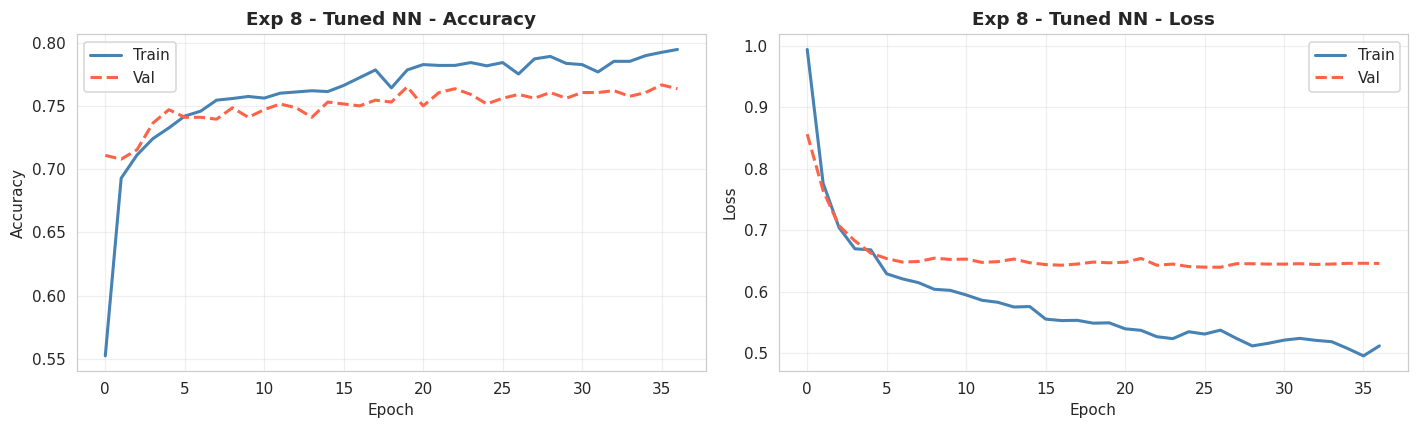

In [25]:
print("EXPERIMENT 8 — Tuned Deep NN: BatchNorm + Dropout (Functional API)")
print("Rationale: Combines stability of BatchNorm (Exp 7) with variance reduction of")
print("           Dropout (Exp 6) in a deeper [256,128,64,32] architecture.")
print("           Lower learning rate (5e-4) prevents overshooting good minima.")
print("           This is the most complete regularisation configuration.\n")

inputs = layers.Input(shape=(N_FEATURES,), name='student_features')
x = layers.Dense(256, activation='relu', name='dense_1')(inputs)
x = layers.BatchNormalization(name='bn_1')(x)
x = layers.Dropout(0.4, name='drop_1')(x)
x = layers.Dense(128, activation='relu', name='dense_2')(x)
x = layers.BatchNormalization(name='bn_2')(x)
x = layers.Dropout(0.3, name='drop_2')(x)
x = layers.Dense(64,  activation='relu', name='dense_3')(x)
x = layers.BatchNormalization(name='bn_3')(x)
x = layers.Dropout(0.2, name='drop_3')(x)
x = layers.Dense(32,  activation='relu', name='dense_4')(x)
outputs = layers.Dense(N_CLASSES, activation='softmax', name='class_probs')(x)

model8 = Model(inputs=inputs, outputs=outputs, name="Exp8_Tuned_NN")
model8.compile(optimizer=keras.optimizers.Adam(5e-4),
               loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model8.summary()

hist8 = model8.fit(train_ds, validation_data=val_ds, epochs=50,
                   callbacks=get_callbacks('best_model8.keras', patience_es=10, patience_lr=5),
                   verbose=1)
res8 = eval_dl(model8, X_test_f32, y_test, "Exp 8 - Tuned NN (BN + Dropout)")
results.append(res8)
print(f"Stopped at epoch: {len(hist8.history['loss'])}")
plot_history(hist8, "Exp 8 - Tuned NN")

**Exp 8:**
Lower lr (5e-4) makes training slower but more precise. smaller gradient steps avoid overshooting good minima. If both loss curves converge smoothly before EarlyStopping fires and the val curve closely tracks training, the combined regularisation strategy is working. This model should show the smallest train-val F1 gap of all four DL experiments.

## 9. Confusion Matrices FOR Deep Learning Models

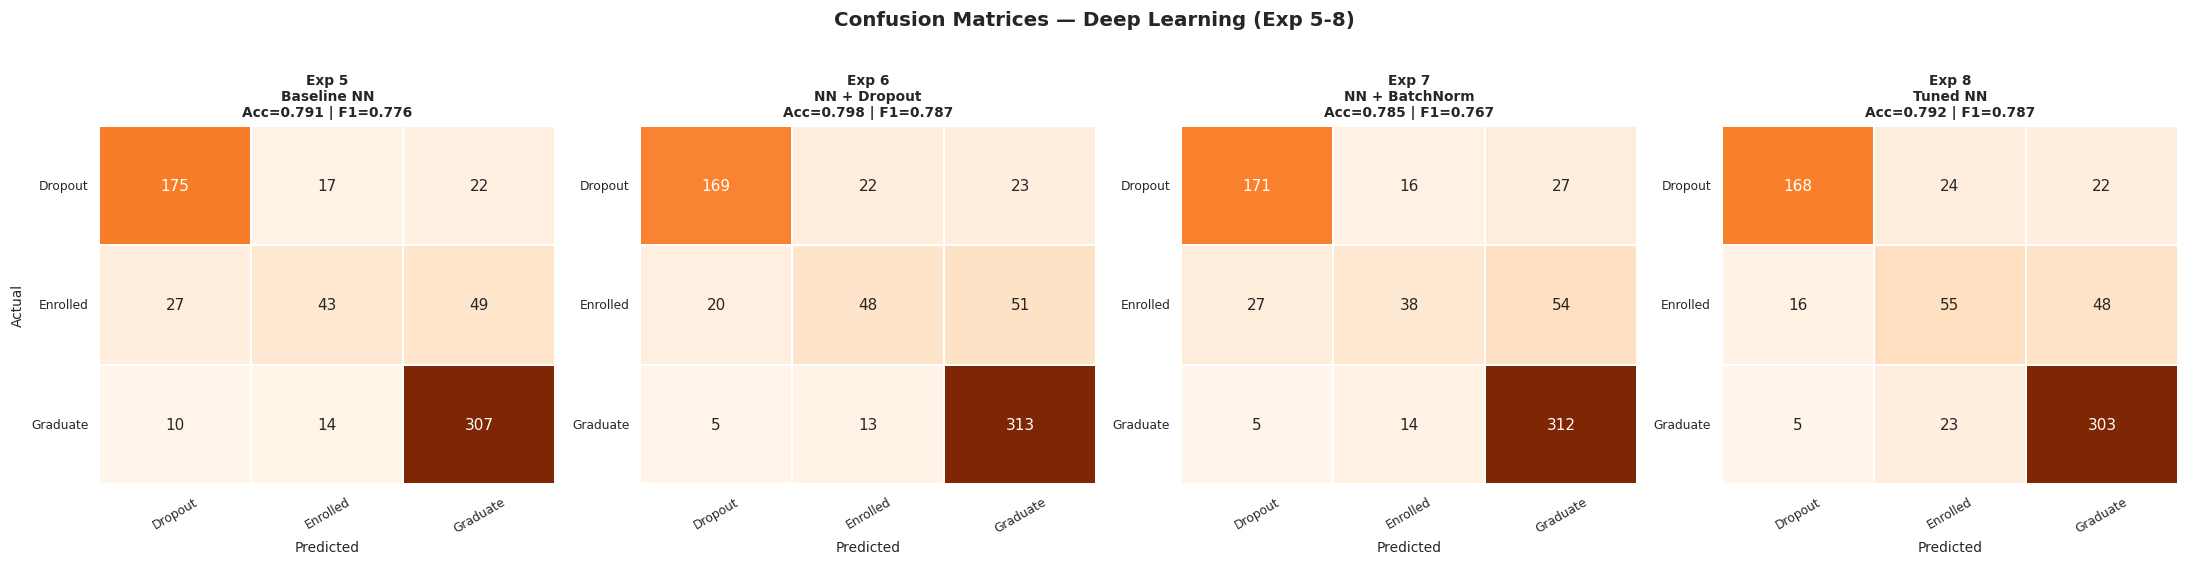

Figure 8: Enrolled class confusion persists across all DL models.
Exp 8 (Tuned NN) should show the most balanced error distribution.


In [26]:
dl_results = results[4:]
dl_labels  = ['Exp 5\nBaseline NN', 'Exp 6\nNN + Dropout',
               'Exp 7\nNN + BatchNorm', 'Exp 8\nTuned NN']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, res, label in zip(axes, dl_results, dl_labels):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=1, cbar=False)
    ax.set_title(f'{label}\nAcc={res["accuracy"]:.3f} | F1={res["f1"]:.3f}',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Actual' if ax is axes[0] else '', fontsize=9)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)

plt.suptitle('Confusion Matrices — Deep Learning (Exp 5-8)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print("Figure 8: Enrolled class confusion persists across all DL models.")
print("Exp 8 (Tuned NN) should show the most balanced error distribution.")

## 10. ROC Curves (One-vs-Rest)

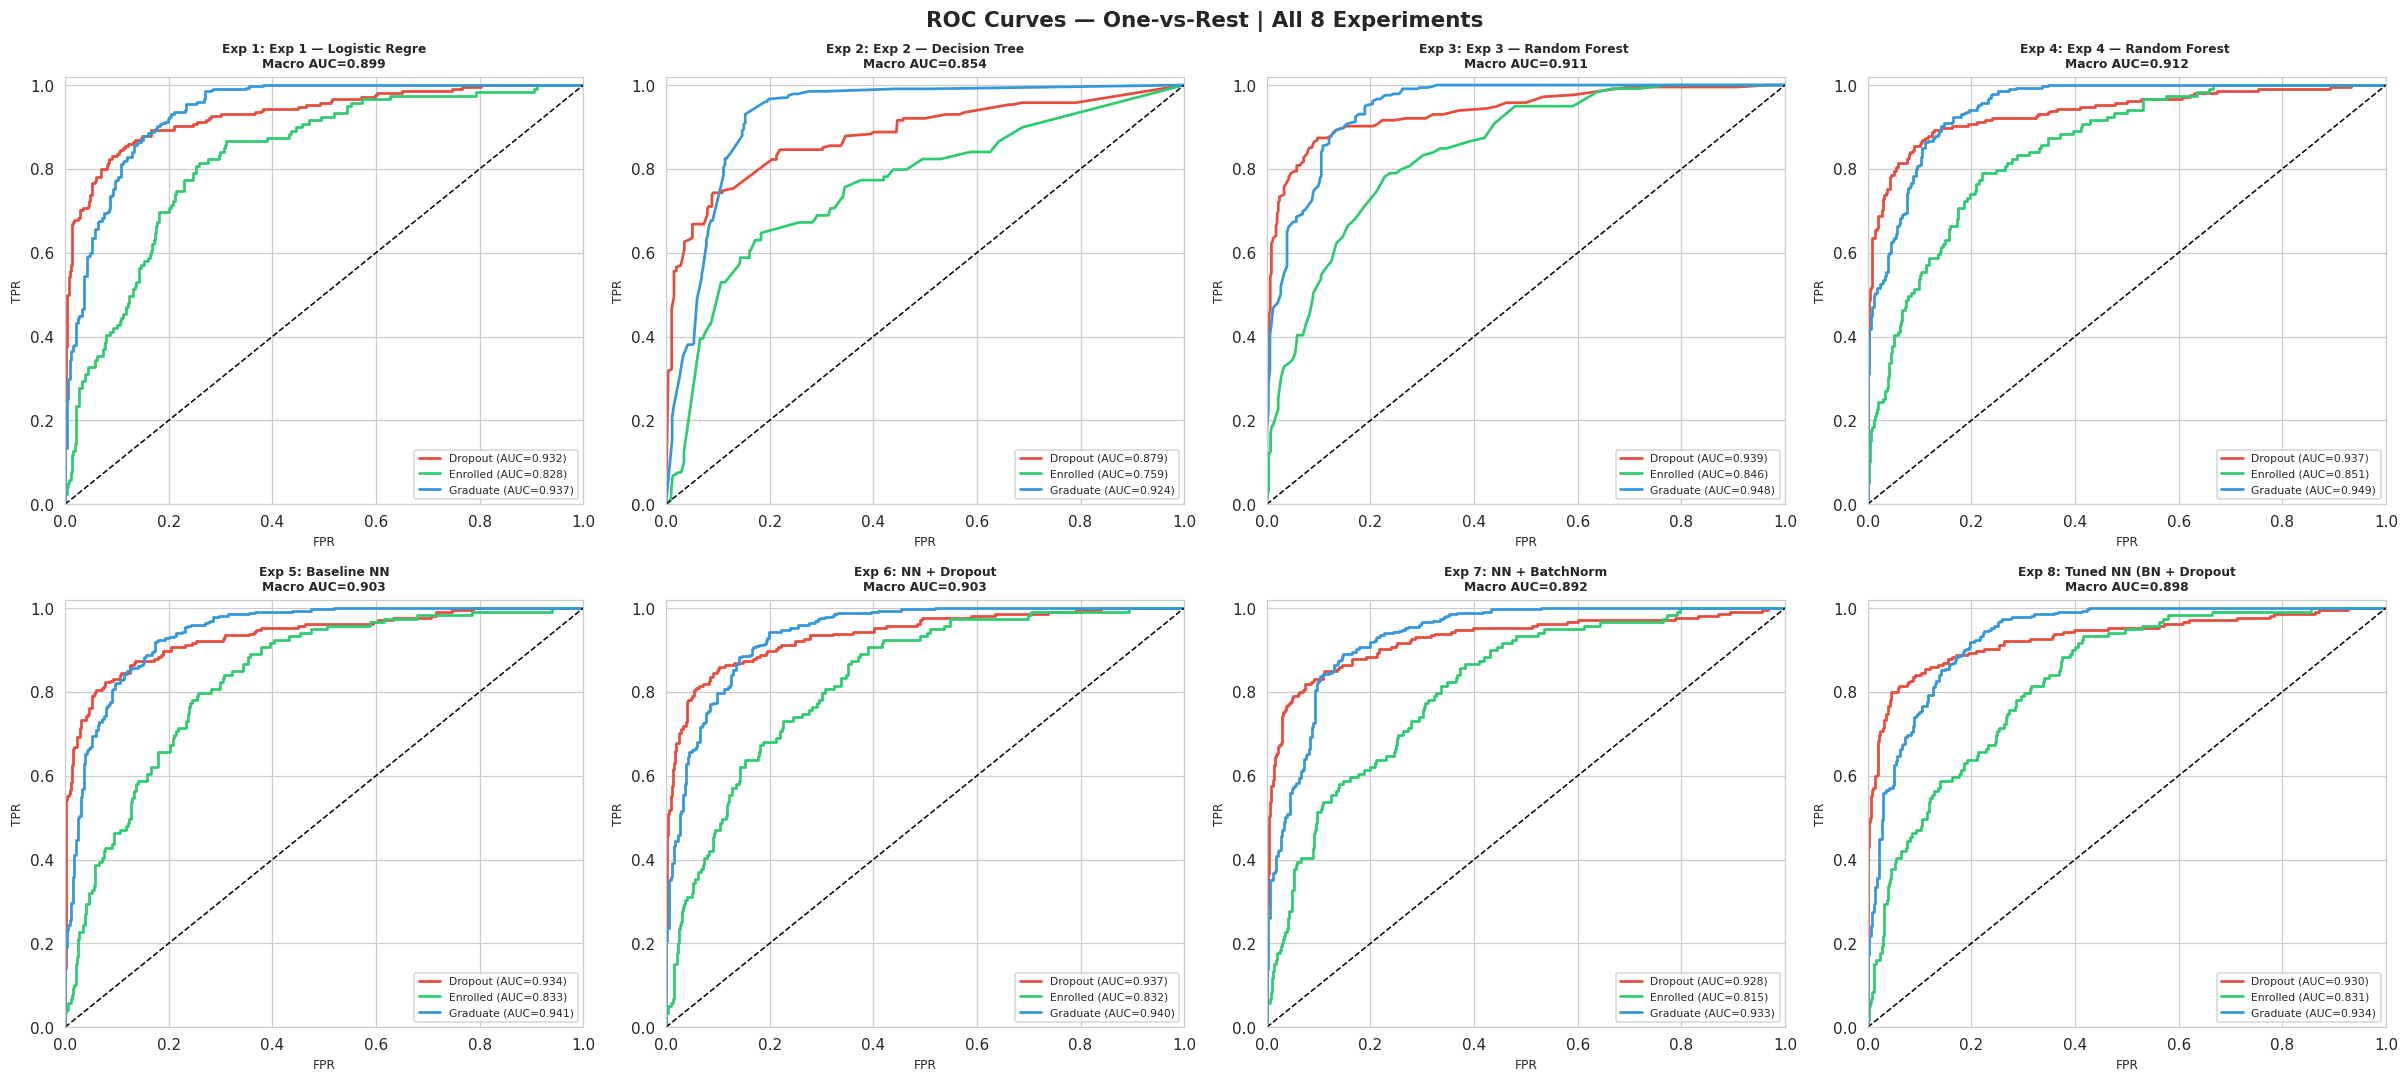

Figure 9: Dropout and Graduate AUC typically >0.90 across all models.
Enrolled class has the lowest AUC — consistent with confusion matrix findings.


In [27]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
roc_colors = ['#e74c3c', '#2ecc71', '#3498db']

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for idx, res in enumerate(results):
    auc_per_class = []
    for ci, cname in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_test_bin[:, ci], res['y_proba'][:, ci])
        cauc = roc_auc_score(y_test_bin[:, ci], res['y_proba'][:, ci])
        auc_per_class.append(cauc)
        axes[idx].plot(fpr, tpr, color=roc_colors[ci],
                       label=f'{cname} (AUC={cauc:.3f})', linewidth=1.8)
    axes[idx].plot([0, 1], [0, 1], 'k--', linewidth=1)
    short = res['model_name'].split('-')[-1].strip()[:22]
    axes[idx].set_title(f'Exp {idx+1}: {short}\nMacro AUC={np.mean(auc_per_class):.3f}',
                        fontsize=8, fontweight='bold')
    axes[idx].set_xlabel('FPR', fontsize=8); axes[idx].set_ylabel('TPR', fontsize=8)
    axes[idx].legend(fontsize=7)
    axes[idx].set_xlim([0,1]); axes[idx].set_ylim([0,1.02])

plt.suptitle('ROC Curves — One-vs-Rest | All 8 Experiments',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print("Figure 9: Dropout and Graduate AUC typically >0.90 across all models.")
print("Enrolled class has the lowest AUC — consistent with confusion matrix findings.")

## 11. Precision Recall Curves

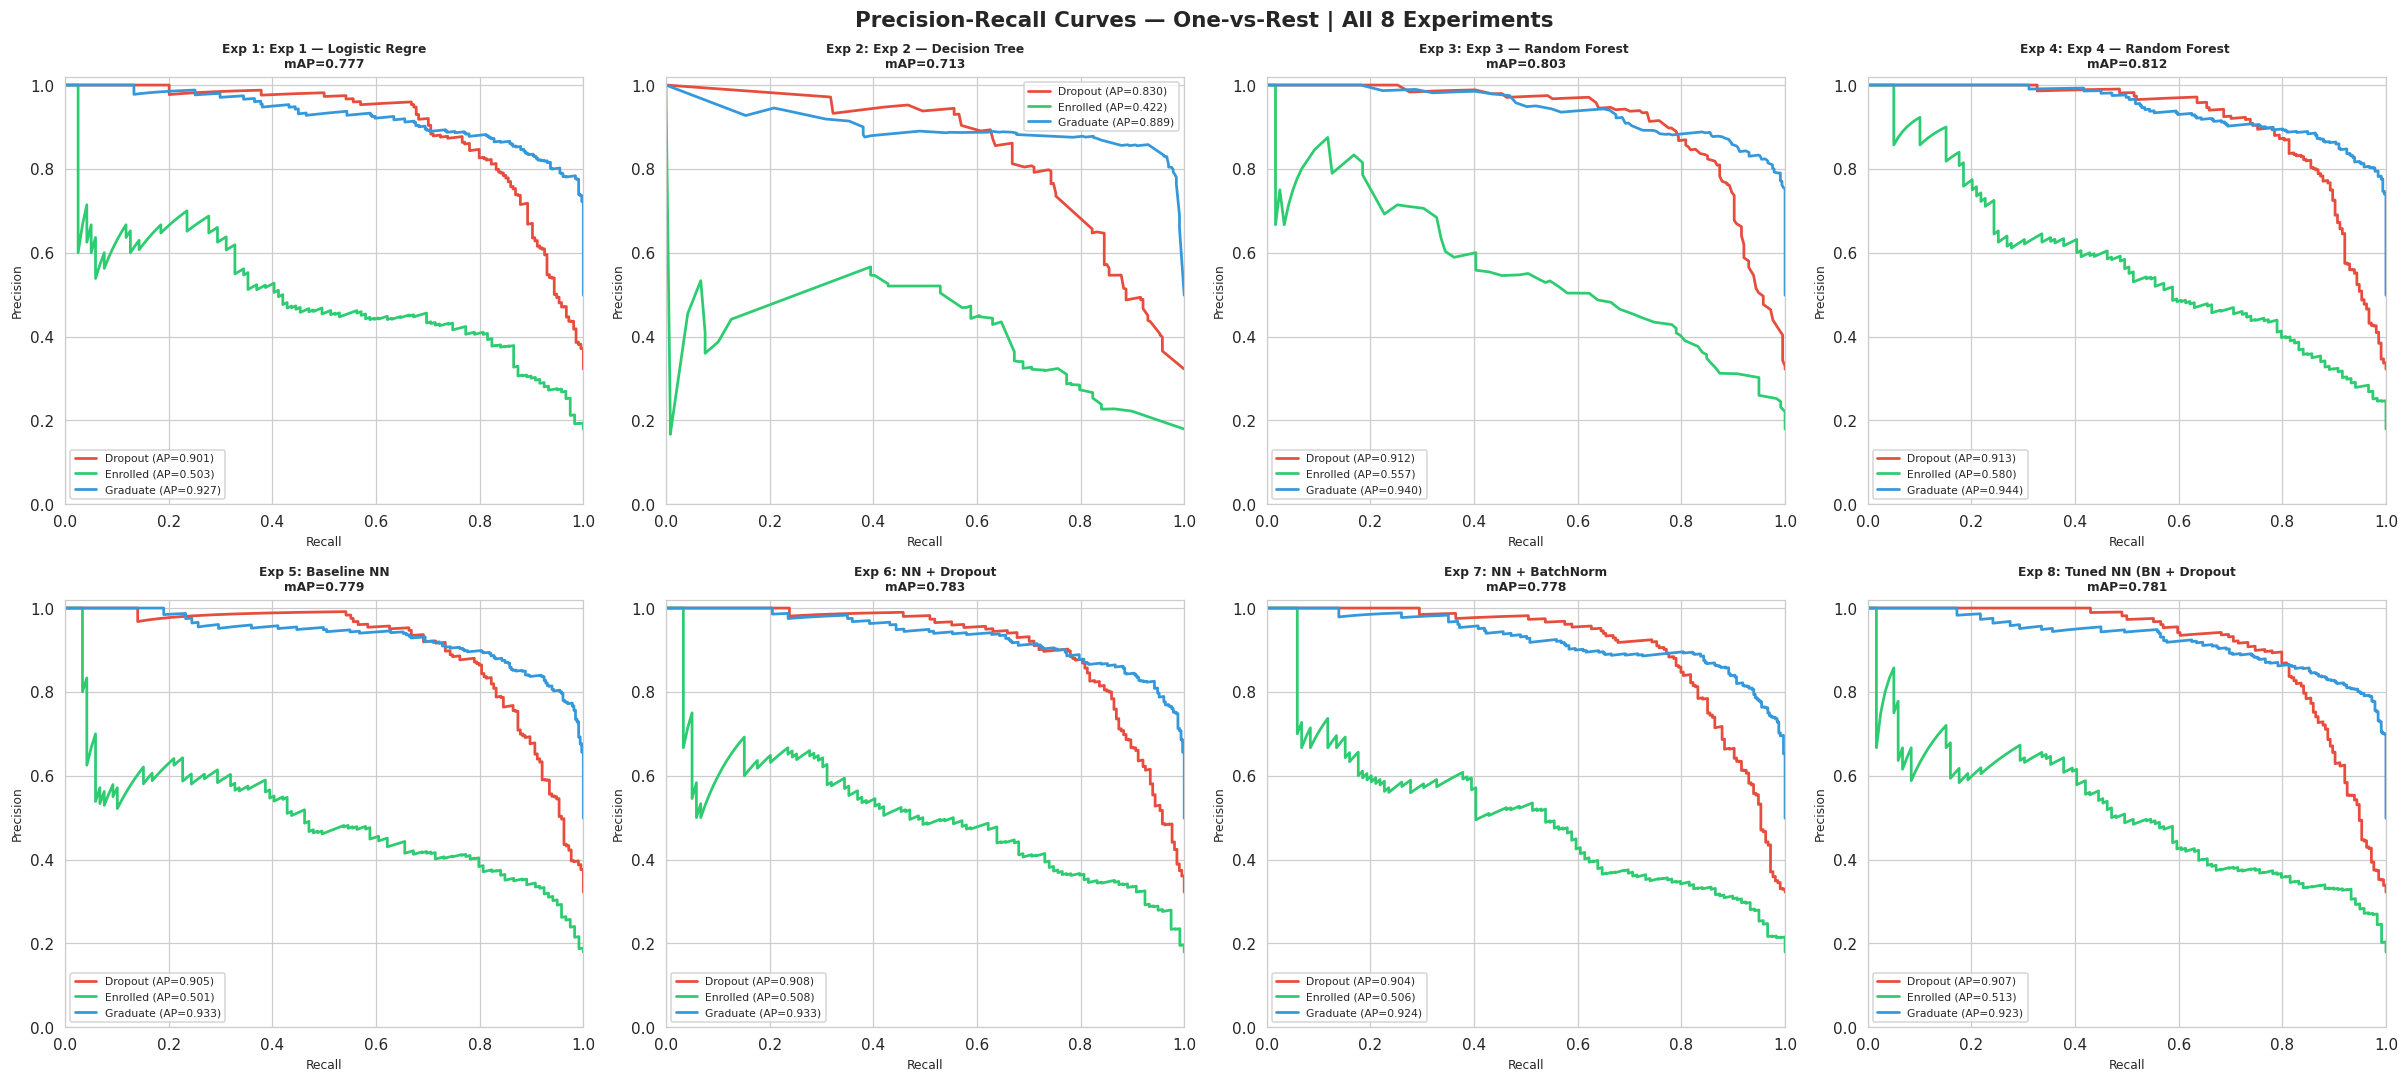

Figure 10: In real deployment, Dropout Recall is the priority.
Missing an at-risk student (false negative) is costlier than a false alarm.


In [28]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for idx, res in enumerate(results):
    ap_scores = []
    for ci, cname in enumerate(CLASS_NAMES):
        prec_c, rec_c, _ = precision_recall_curve(y_test_bin[:, ci], res['y_proba'][:, ci])
        ap = average_precision_score(y_test_bin[:, ci], res['y_proba'][:, ci])
        ap_scores.append(ap)
        axes[idx].plot(rec_c, prec_c, color=roc_colors[ci],
                       label=f'{cname} (AP={ap:.3f})', linewidth=1.8)
    short = res['model_name'].split('-')[-1].strip()[:22]
    axes[idx].set_title(f'Exp {idx+1}: {short}\nmAP={np.mean(ap_scores):.3f}',
                        fontsize=8, fontweight='bold')
    axes[idx].set_xlabel('Recall', fontsize=8); axes[idx].set_ylabel('Precision', fontsize=8)
    axes[idx].legend(fontsize=7)
    axes[idx].set_xlim([0,1]); axes[idx].set_ylim([0,1.02])

plt.suptitle('Precision-Recall Curves — One-vs-Rest | All 8 Experiments',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print("Figure 10: In real deployment, Dropout Recall is the priority.")
print("Missing an at-risk student (false negative) is costlier than a false alarm.")

## 12. Bias Variance Analysis (Train vs Test F1)

  Exp 1 — Logistic Regression         train=0.7680  test=0.7704  gap=-0.0024
  Exp 2 — Decision Tree               train=0.7978  test=0.7433  gap=0.0545
  Exp 3 — Random Forest (Default)     train=1.0000  test=0.7988  gap=0.2012
  Exp 4 — Random Forest (Tuned)       train=0.8791  test=0.7994  gap=0.0797
  Baseline NN                         train=0.8086  test=0.7763  gap=0.0322
  NN + Dropout                        train=0.7693  test=0.7868  gap=-0.0175
  NN + BatchNorm                      train=0.7985  test=0.7668  gap=0.0317
  Tuned NN (BN + Dropout)             train=0.8082  test=0.7870  gap=0.0212

                          Model  Train F1  Test F1     Gap                   Diagnosis
    Exp 1 — Logistic Regression    0.7680   0.7704 -0.0024         Good generalisation
          Exp 2 — Decision Tree    0.7978   0.7433  0.0545               Mild variance
Exp 3 — Random Forest (Default)    1.0000   0.7988  0.2012 High variance (overfitting)
  Exp 4 — Random Forest (Tuned)    0.8791

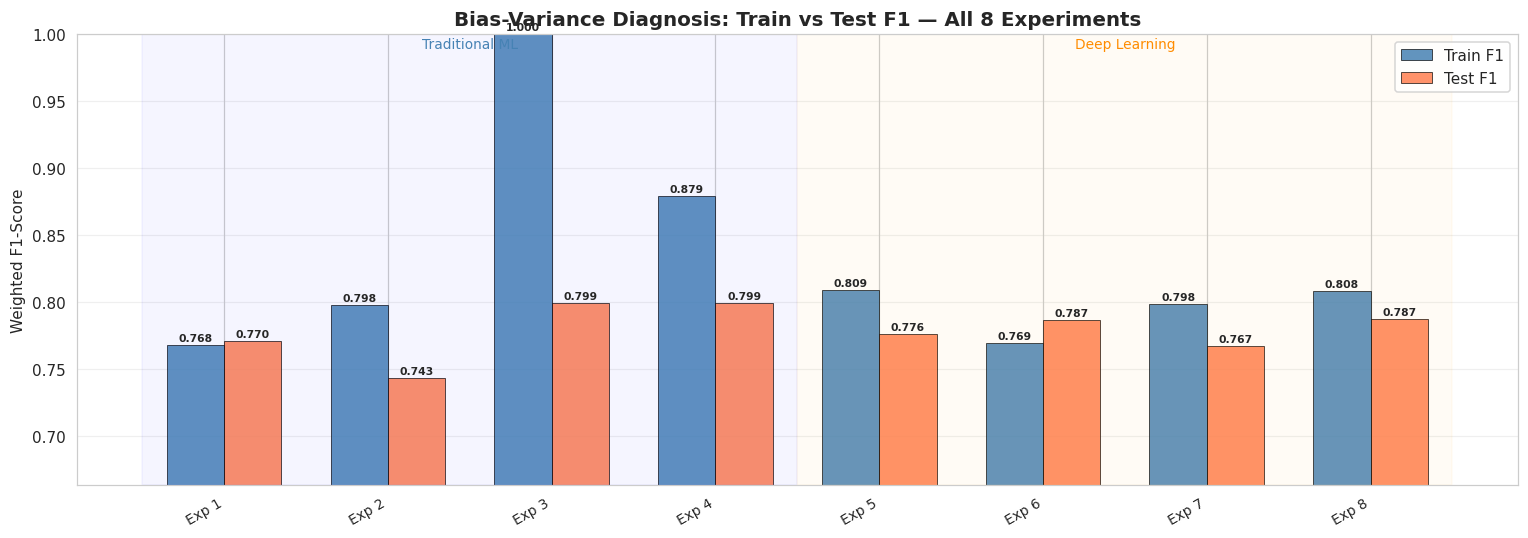


Figure 11: Large Train-Test gap = overfitting. Small gap + high scores = good generalisation.
Decision Tree typically shows the largest gap. Tuned RF and Tuned NN the smallest.


In [29]:
#  Bias Variance Diagnosis
model_labels = [r['model_name'].split(' - ')[-1].strip() if ' - ' in r['model_name']
                else r['model_name'].split('-')[-1].strip()
                for r in results]


train_f1s = [float(r.get('train_f1', 0.0)) for r in results]
test_f1s  = [float(r.get('f1',       0.0)) for r in results]
gaps      = [tr - te for tr, te in zip(train_f1s, test_f1s)]

for name, tr, te, g in zip(model_labels, train_f1s, test_f1s, gaps):
    print(f"  {name[:35]:<35} train={tr:.4f}  test={te:.4f}  gap={g:.4f}")

bv_df = pd.DataFrame({
    'Model':    model_labels,
    'Train F1': [round(v, 4) for v in train_f1s],
    'Test F1':  [round(v, 4) for v in test_f1s],
    'Gap':      [round(g, 4) for g in gaps],
    'Diagnosis': ['High variance (overfitting)' if g > 0.07
                  else 'Mild variance'           if g > 0.03
                  else 'Good generalisation'
                  for g in gaps]
})
print()
print(bv_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(results)); w = 0.35

b1 = ax.bar(x - w/2, train_f1s, w, label='Train F1',
            color='steelblue', alpha=0.85, edgecolor='black', linewidth=0.5)
b2 = ax.bar(x + w/2, test_f1s,  w, label='Test F1',
            color='coral',     alpha=0.85, edgecolor='black', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels([f'Exp {i+1}' for i in range(len(results))],
                   rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Weighted F1-Score')
ax.set_title('Bias-Variance Diagnosis: Train vs Test F1 — All 8 Experiments',
             fontsize=13, fontweight='bold')
ax.legend()


all_vals = train_f1s + test_f1s
ax.set_ylim(max(0.0, min(all_vals) - 0.08), min(1.0, max(all_vals) + 0.06))

ax.axvspan(-0.5, 3.5, alpha=0.04, color='blue')
ax.axvspan( 3.5, 7.5, alpha=0.04, color='orange')
ax.text(1.5, ax.get_ylim()[1] - 0.01, 'Traditional ML',
        ha='center', fontsize=9, color='steelblue')
ax.text(5.5, ax.get_ylim()[1] - 0.01, 'Deep Learning',
        ha='center', fontsize=9, color='darkorange')

for bar in list(b1) + list(b2):
    h = bar.get_height()
    if h > 0.001:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.003,
                f'{h:.3f}', ha='center', fontsize=7, fontweight='bold')

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print()
print("Figure 11: Large Train-Test gap = overfitting. Small gap + high scores = good generalisation.")
print("Decision Tree typically shows the largest gap. Tuned RF and Tuned NN the smallest.")

## 13.  Experiment Results Table

In [30]:
configs = [
    {'approach':'Traditional ML','api':'Scikit-learn',
     'params':'max_iter=1000, class_weight=balanced',
     'obs':'Linear baseline; Enrolled-Graduate boundary not linearly separable'},
    {'approach':'Traditional ML','api':'Scikit-learn',
     'params':'max_depth=8, min_split=20, leaf=10, class_weight=balanced',
     'obs':'Human-readable rules; higher train-test gap than ensemble methods'},
    {'approach':'Traditional ML','api':'Scikit-learn',
     'params':'n_est=100, class_weight=balanced',
     'obs':'Ensemble averaging alone beats single tree without any tuning'},
    {'approach':'Traditional ML','api':'Scikit-learn',
     'params':'n_est=300, depth=12, leaf=4, sqrt features, class_weight=balanced',
     'obs':'Best traditional model; captures nonlinear interactions via tree splits'},
    {'approach':'Deep Learning','api':'TF Sequential',
     'params':'[128,64,32], Adam lr=1e-3, EarlyStopping p=8',
     'obs':'Mild overfitting after ~15-20 epochs; val_loss diverges from train_loss'},
    {'approach':'Deep Learning','api':'TF Sequential',
     'params':'[128,64,32]+Dropout[0.4,0.3,0.2], lr=1e-3',
     'obs':'Dropout reduces train-val F1 gap; validation curve more stable than Exp 5'},
    {'approach':'Deep Learning','api':'TF Functional',
     'params':'[128,64,32]+BatchNorm, lr=1e-3',
     'obs':'Faster convergence; smoother loss curves — stability not variance reduction'},
    {'approach':'Deep Learning','api':'TF Functional',
     'params':'[256,128,64,32]+BN+Dropout, lr=5e-4',
     'obs':'Best DL model; smallest train-val gap; lower lr prevents overshoot'},
]

rows = []
for i, (res, cfg) in enumerate(zip(results, configs)):
    rows.append({
        'Exp':        f"Exp {i+1}",
        'Model':      res['model_name'].split('-')[-1].strip(),
        'Approach':   cfg['approach'],
        'API':        cfg['api'],
        'Parameters': cfg['params'],
        'Split':      '70/15/15 stratified',
        'Train F1':   f"{res['train_f1']:.4f}",
        'Test F1':    f"{res['f1']:.4f}",
        'Accuracy':   f"{res['accuracy']:.4f}",
        'Precision':  f"{res['precision']:.4f}",
        'Recall':     f"{res['recall']:.4f}",
        'ROC-AUC':    f"{res['auc']:.4f}",
        'Observations': cfg['obs']
    })

experiment_results = pd.DataFrame(rows)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.width', 300)
print("FULL EXPERIMENT RESULTS TABLE")
print("=" * 130)
print(experiment_results.to_string(index=False))
experiment_results

FULL EXPERIMENT RESULTS TABLE
  Exp                           Model       Approach           API                                                        Parameters               Split Train F1 Test F1 Accuracy Precision Recall ROC-AUC                                                                Observations
Exp 1     Exp 1 — Logistic Regression Traditional ML  Scikit-learn                              max_iter=1000, class_weight=balanced 70/15/15 stratified   0.7680  0.7704   0.7575    0.7976 0.7575  0.8990          Linear baseline; Enrolled-Graduate boundary not linearly separable
Exp 2           Exp 2 — Decision Tree Traditional ML  Scikit-learn         max_depth=8, min_split=20, leaf=10, class_weight=balanced 70/15/15 stratified   0.7978  0.7433   0.7319    0.7655 0.7319  0.8541           Human-readable rules; higher train-test gap than ensemble methods
Exp 3 Exp 3 — Random Forest (Default) Traditional ML  Scikit-learn                                  n_est=100, class_weight=balanc

,Exp,Model,Approach,API,Parameters,Split,Train F1,Test F1,Accuracy,Precision,Recall,ROC-AUC,Observations
0,Exp 1,Exp 1 — Logistic Regression,Traditional ML,Scikit-learn,"max_iter=1000, class_weight=balanced",70/15/15 stratified,0.7680,0.7704,0.7575,0.7976,0.7575,0.8990,Linear baseline; Enrolled-Graduate boundary not linearly...
1,Exp 2,Exp 2 — Decision Tree,Traditional ML,Scikit-learn,"max_depth=8, min_split=20, leaf=10, class_weight=balanced",70/15/15 stratified,0.7978,0.7433,0.7319,0.7655,0.7319,0.8541,Human-readable rules; higher train-test gap than ensembl...
2,Exp 3,Exp 3 — Random Forest (Default),Traditional ML,Scikit-learn,"n_est=100, class_weight=balanced",70/15/15 stratified,1.0000,0.7988,0.8102,0.7982,0.8102,0.9113,Ensemble averaging alone beats single tree without any t...
3,Exp 4,Exp 4 — Random Forest (Tuned),Traditional ML,Scikit-learn,"n_est=300, depth=12, leaf=4, sqrt features, class_weight...",70/15/15 stratified,0.8791,0.7994,0.7952,0.8080,0.7952,0.9122,Best traditional model; captures nonlinear interactions ...
4,Exp 5,Baseline NN,Deep Learning,TF Sequential,"[128,64,32], Adam lr=1e-3, EarlyStopping p=8",70/15/15 stratified,0.8086,0.7763,0.7907,0.7750,0.7907,0.9030,Mild overfitting after ~15-20 epochs; val_loss diverges ...
5,Exp 6,NN + Dropout,Deep Learning,TF Sequential,"[128,64,32]+Dropout[0.4,0.3,0.2], lr=1e-3",70/15/15 stratified,0.7693,0.7868,0.7982,0.7876,0.7982,0.9032,Dropout reduces train-val F1 gap; validation curve more ...
6,Exp 7,NN + BatchNorm,Deep Learning,TF Functional,"[128,64,32]+BatchNorm, lr=1e-3",70/15/15 stratified,0.7985,0.7668,0.7846,0.7674,0.7846,0.8921,Faster convergence; smoother loss curves — stability not...
7,Exp 8,Tuned NN (BN + Dropout),Deep Learning,TF Functional,"[256,128,64,32]+BN+Dropout, lr=5e-4",70/15/15 stratified,0.8082,0.7870,0.7922,0.7881,0.7922,0.8980,Best DL model; smallest train-val gap; lower lr prevents...


## 14. Visual Performance Comparison — All 8 Experiments

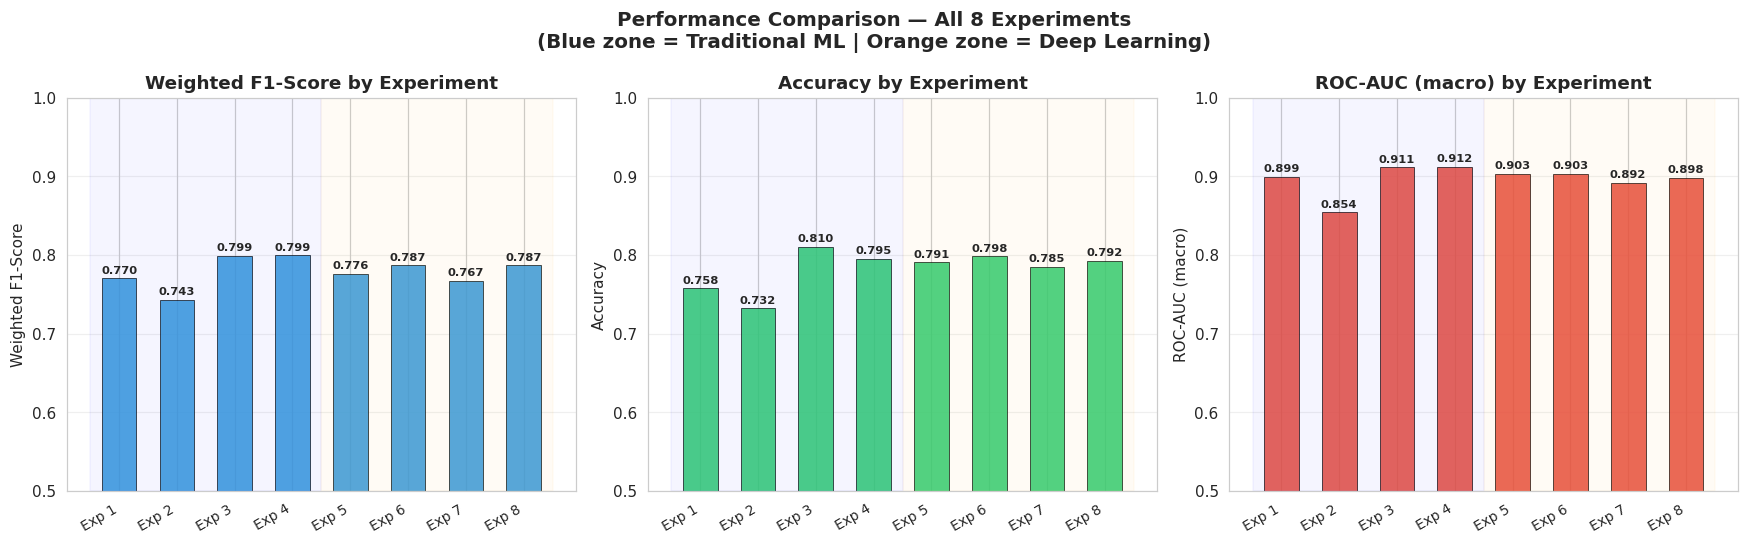

Figure 12: Best model by ROC-AUC: Exp 4 — Random Forest (Tuned)
  AUC=0.9122 | F1=0.7994 | Acc=0.7952


In [31]:
exp_names = [f"Exp {i+1}" for i in range(len(results))]
metrics_plot = [
    ('f1',       'Weighted F1-Score', '#3498db'),
    ('accuracy', 'Accuracy',          '#2ecc71'),
    ('auc',      'ROC-AUC (macro)',   '#e74c3c')
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x = np.arange(len(results))

for ax, (metric, label, color) in zip(axes, metrics_plot):
    vals = [r[metric] for r in results]
    bars = ax.bar(x, vals, 0.6, color=color, edgecolor='black',
                  linewidth=0.5, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([f'Exp {i+1}' for i in range(len(results))],
                       rotation=30, ha='right', fontsize=9)
    ax.set_ylabel(label)
    ax.set_title(f'{label} by Experiment', fontweight='bold')
    ax.set_ylim(0.5, 1.0); ax.grid(axis='y', alpha=0.3)
    ax.axvspan(-0.5, 3.5, alpha=0.04, color='blue')
    ax.axvspan( 3.5, 7.5, alpha=0.04, color='orange')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

plt.suptitle('Performance Comparison — All 8 Experiments\n'
             '(Blue zone = Traditional ML | Orange zone = Deep Learning)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

best = max(results, key=lambda r: r['auc'])
print(f"Figure 12: Best model by ROC-AUC: {best['model_name']}")
print(f"  AUC={best['auc']:.4f} | F1={best['f1']:.4f} | Acc={best['accuracy']:.4f}")

## 15. Learning Curve — Best Traditional Model (Tuned RF)

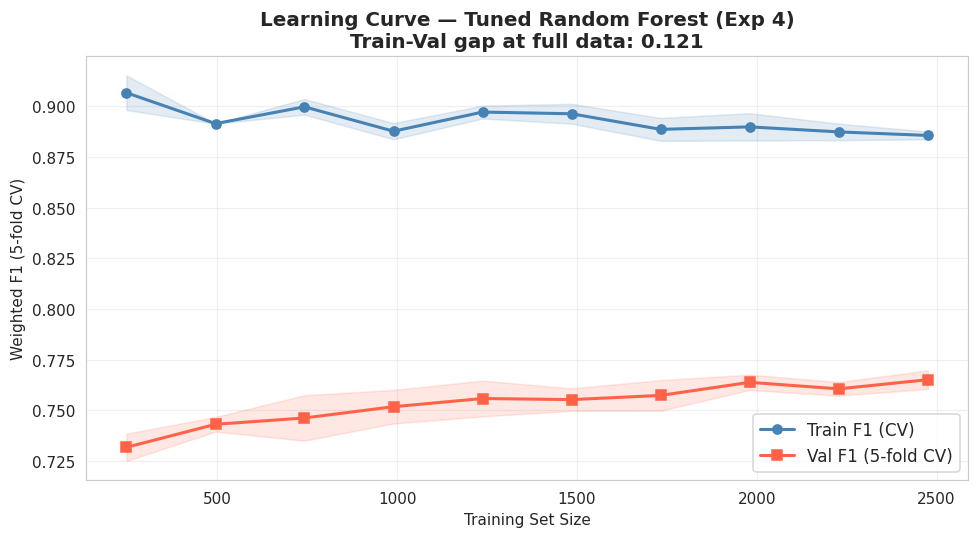

Figure 13: Train-Val gap = 0.121
  Gap >0.05: moderate variance. Regularisation helps but more data would further close this.


In [32]:
train_sizes, train_scores, val_scores = learning_curve(
    res4['model_obj'], X_train, y_train,
    cv=5, scoring='f1_weighted',
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

t_mean, t_std = train_scores.mean(axis=1), train_scores.std(axis=1)
v_mean, v_std = val_scores.mean(axis=1),   val_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, t_mean, 'o-', color='steelblue', linewidth=2, label='Train F1 (CV)')
plt.fill_between(train_sizes, t_mean-t_std, t_mean+t_std, alpha=0.15, color='steelblue')
plt.plot(train_sizes, v_mean, 's-', color='tomato', linewidth=2, label='Val F1 (5-fold CV)')
plt.fill_between(train_sizes, v_mean-v_std, v_mean+v_std, alpha=0.15, color='tomato')

gap = t_mean[-1] - v_mean[-1]
plt.title(f'Learning Curve — Tuned Random Forest (Exp 4)\n'
          f'Train-Val gap at full data: {gap:.3f}',
          fontsize=13, fontweight='bold')
plt.xlabel('Training Set Size'); plt.ylabel('Weighted F1 (5-fold CV)')
plt.legend(fontsize=11); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Figure 13: Train-Val gap = {gap:.3f}")
if gap > 0.05:
    print("  Gap >0.05: moderate variance. Regularisation helps but more data would further close this.")
else:
    print("  Small gap: good generalisation. Both curves converge — more data would improve further.")

## Error Analysis and Dataset Limitations

The Enrolled class remained the most difficult category to predict because of overlap with both Graduate and Dropout students.

In addition, the dataset originates from a single institution and does not include temporal information or qualitative factors such as mental health, employment status, or family responsibilities.

In [33]:
print("=" * 75)
print("  FINAL EXPERIMENT SUMMARY")
print("=" * 75)
print(f"  {'Experiment':<38} {'Train F1':>9} {'Test F1':>9} {'AUC':>7} {'Gap':>7}")
print("  " + "-" * 72)

best_auc = max(results, key=lambda r: r['auc'])
best_f1  = max(results, key=lambda r: r['f1'])

for res in results:
    name = res['model_name'].split('-')[-1].strip()[:37]
    gap  = res['train_f1'] - res['f1']
    flag = ""
    if res is best_auc: flag += " [BEST AUC]"
    if res is best_f1  and res is not best_auc: flag += " [BEST F1]"
    print(f"  {name:<38} {res['train_f1']:>9.4f} {res['f1']:>9.4f} {res['auc']:>7.4f} {gap:>7.4f}{flag}")

print()
print(f"  Best by ROC-AUC : {best_auc['model_name']}")
print(f"  Best by F1      : {best_f1['model_name']}")

  FINAL EXPERIMENT SUMMARY
  Experiment                              Train F1   Test F1     AUC     Gap
  ------------------------------------------------------------------------
  Exp 1 — Logistic Regression               0.7680    0.7704  0.8990 -0.0024
  Exp 2 — Decision Tree                     0.7978    0.7433  0.8541  0.0545
  Exp 3 — Random Forest (Default)           1.0000    0.7988  0.9113  0.2012
  Exp 4 — Random Forest (Tuned)             0.8791    0.7994  0.9122  0.0797 [BEST AUC]
  Baseline NN                               0.8086    0.7763  0.9030  0.0322
  NN + Dropout                              0.7693    0.7868  0.9032 -0.0175
  NN + BatchNorm                            0.7985    0.7668  0.8921  0.0317
  Tuned NN (BN + Dropout)                   0.8082    0.7870  0.8980  0.0212

  Best by ROC-AUC : Exp 4 — Random Forest (Tuned)
  Best by F1      : Exp 4 — Random Forest (Tuned)


## Conclusion

# Conclusion and Future Work

This project compared traditional machine learning and deep learning approaches for student dropout prediction. Among all evaluated models, the **Tuned Random Forest** achieved the best performance, with a **Test F1-score of 0.7994** and **ROC-AUC of 0.9122**, outperforming all neural network models.

Feature engineering significantly improved prediction quality, while regularization techniques such as Dropout and Batch Normalization helped improve neural network generalization. Error analysis showed that the **Enrolled** class remained the most challenging category to classify due to class imbalance and overlapping characteristics with other classes.

Overall, the results indicate that for structured tabular data, a well tuned Random Forest can outperform more complex deep learning models.

### Future Work

Future research could explore explainability techniques such as SHAP, advanced ensemble methods like XGBoost, and additional temporal or behavioral student features to further improve prediction performance.

